# Команда 12. Смирнова М., Дворяшина И., Шумакова В., Шилкова А.

# Импорты библиотек

In [2]:
# Стандартные библиотеки Python
import json
import re
import warnings

# Сторонние библиотеки
import gdown
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm

In [3]:
# Отключение системных сообщений и предупреждений
warnings.filterwarnings('ignore')

# Чтение данных

In [4]:
# Cкачиваем данные
data_url = f'https://drive.google.com/uc?export=download&id=1s8v3bwLuXzV1o6j5XOyFcbMC0bF4wntN'
output = 'data.csv'
gdown.download(data_url, output, quiet=False)
df = pd.read_csv('data.csv')

Downloading...
From: https://drive.google.com/uc?export=download&id=1s8v3bwLuXzV1o6j5XOyFcbMC0bF4wntN
To: /content/data.csv
100%|██████████| 2.79M/2.79M [00:00<00:00, 74.6MB/s]


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28000 entries, 0 to 27999
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   user_id                28000 non-null  object 
 1   start_trial_date       28000 non-null  object 
 2   city                   27692 non-null  object 
 3   device                 28000 non-null  object 
 4   source                 28000 non-null  object 
 5   favourite_genre        20048 non-null  object 
 6   avg_min_watch_daily    28000 non-null  float64
 7   number_of_days_logged  28000 non-null  int64  
 8   churn                  28000 non-null  int64  
dtypes: float64(1), int64(2), object(6)
memory usage: 1.9+ MB


In [6]:
# Проверка наличия пустых значений
print("Пропуски в данных: \n", df.isna().sum())

Пропуски в данных: 
 user_id                     0
start_trial_date            0
city                      308
device                      0
source                      0
favourite_genre          7952
avg_min_watch_daily         0
number_of_days_logged       0
churn                       0
dtype: int64


## Пропуски в данных обнаружены у признака 'city' (308) и 'favourite_genre' (7952)

In [7]:
df.describe()

,avg_min_watch_daily,number_of_days_logged,churn
count,28000.000000,28000.00000,28000.000000
mean,7.812663,1.88600,0.789286
std,7.739760,1.48293,0.407823
min,0.000181,1.00000,0.000000
25%,2.521966,1.00000,1.000000
50%,5.419012,1.00000,1.000000
75%,10.487946,2.00000,1.000000
max,80.072401,7.00000,1.000000


In [8]:
df.describe(include = 'object')

,user_id,start_trial_date,city,device,source,favourite_genre
count,28000,28000,27692,28000,28000,20048
unique,28000,28,9,4,3,5
top,86fc83b2-01e3-4f9a-9bd6-e8065abc029e,2024-02-28,Moscow,web,performance,drama
freq,1,1103,8736,17752,14540,4928


In [9]:
print("Уникальные значения категориального признака city: ", df['city'].unique())
print("Уникальные значения категориального признака device: ", df['device'].unique())
print("Уникальные значения категориального признака source: ", df['source'].unique())
print("Уникальные значения категориального признака favourite_genre: ", df['favourite_genre'].unique())

Уникальные значения категориального признака city:  ['St Petersburg' 'Other' 'Ufa' 'Moscow' 'Samara' 'Krasnodar'
 'Yekaterinburg' 'Novosibirsk' 'Voronezh' nan]
Уникальные значения категориального признака device:  ['ios' 'web' 'smarttv' 'android']
Уникальные значения категориального признака source:  ['performance' 'seo' 'organic']
Уникальные значения категориального признака favourite_genre:  ['drama' 'criminal' 'thriller' 'comedy' nan 'action']


# Чистка данных

In [10]:
# Преобразование дат в datetime
df['start_trial_date'] = pd.to_datetime(df['start_trial_date'])

# Замена NaN на "Unknown"
df['city'] = df['city'].fillna('Unknown')
df['favourite_genre'] = df['favourite_genre'].fillna('Unknown')

# Feature Engineering
# Создание новой колонки день недели начала триала
df['trial_start_day_of_week'] = df['start_trial_date'].dt.dayofweek
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28000 entries, 0 to 27999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   user_id                  28000 non-null  object        
 1   start_trial_date         28000 non-null  datetime64[ns]
 2   city                     28000 non-null  object        
 3   device                   28000 non-null  object        
 4   source                   28000 non-null  object        
 5   favourite_genre          28000 non-null  object        
 6   avg_min_watch_daily      28000 non-null  float64       
 7   number_of_days_logged    28000 non-null  int64         
 8   churn                    28000 non-null  int64         
 9   trial_start_day_of_week  28000 non-null  int32         
dtypes: datetime64[ns](1), float64(1), int32(1), int64(2), object(5)
memory usage: 2.0+ MB


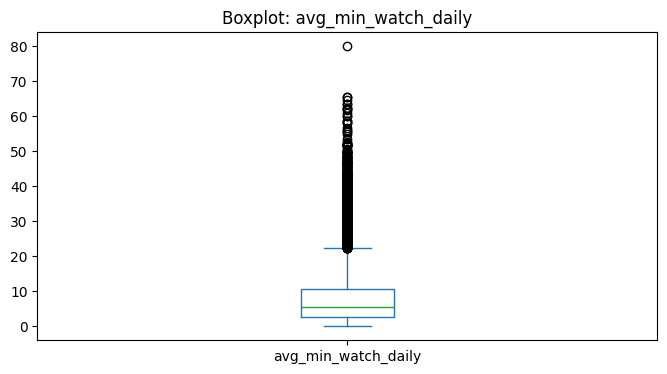

In [11]:
# Построение боксплота распределения и аномалии в данных о среднем времени просмотра
plt.figure(figsize=(8, 4))
df["avg_min_watch_daily"].plot(kind="box")
plt.title("Boxplot: avg_min_watch_daily")
plt.show()

In [12]:
# Расчет процентилей
percentiles = df['avg_min_watch_daily'].quantile([0.5, 0.75, 0.9, 0.95, 0.99, 0.999])
print("Процентили времени просмотра:")
print(percentiles)

Процентили времени просмотра:
0.500     5.419012
0.750    10.487946
0.900    18.095907
0.950    23.691268
0.990    36.007353
0.999    51.902463
Name: avg_min_watch_daily, dtype: float64


Поскольку 80 минут (максимальное значение) - адекватное время просмотра, и в целом для стриминга возможно скошенное распределение, принято решение не проводить очистку от выбросов и работать с исходными данными, чтобы не потерять полезную информацию для анализа конверсии

# Построение диаграмм категориальных признаков для анализа распределение данных

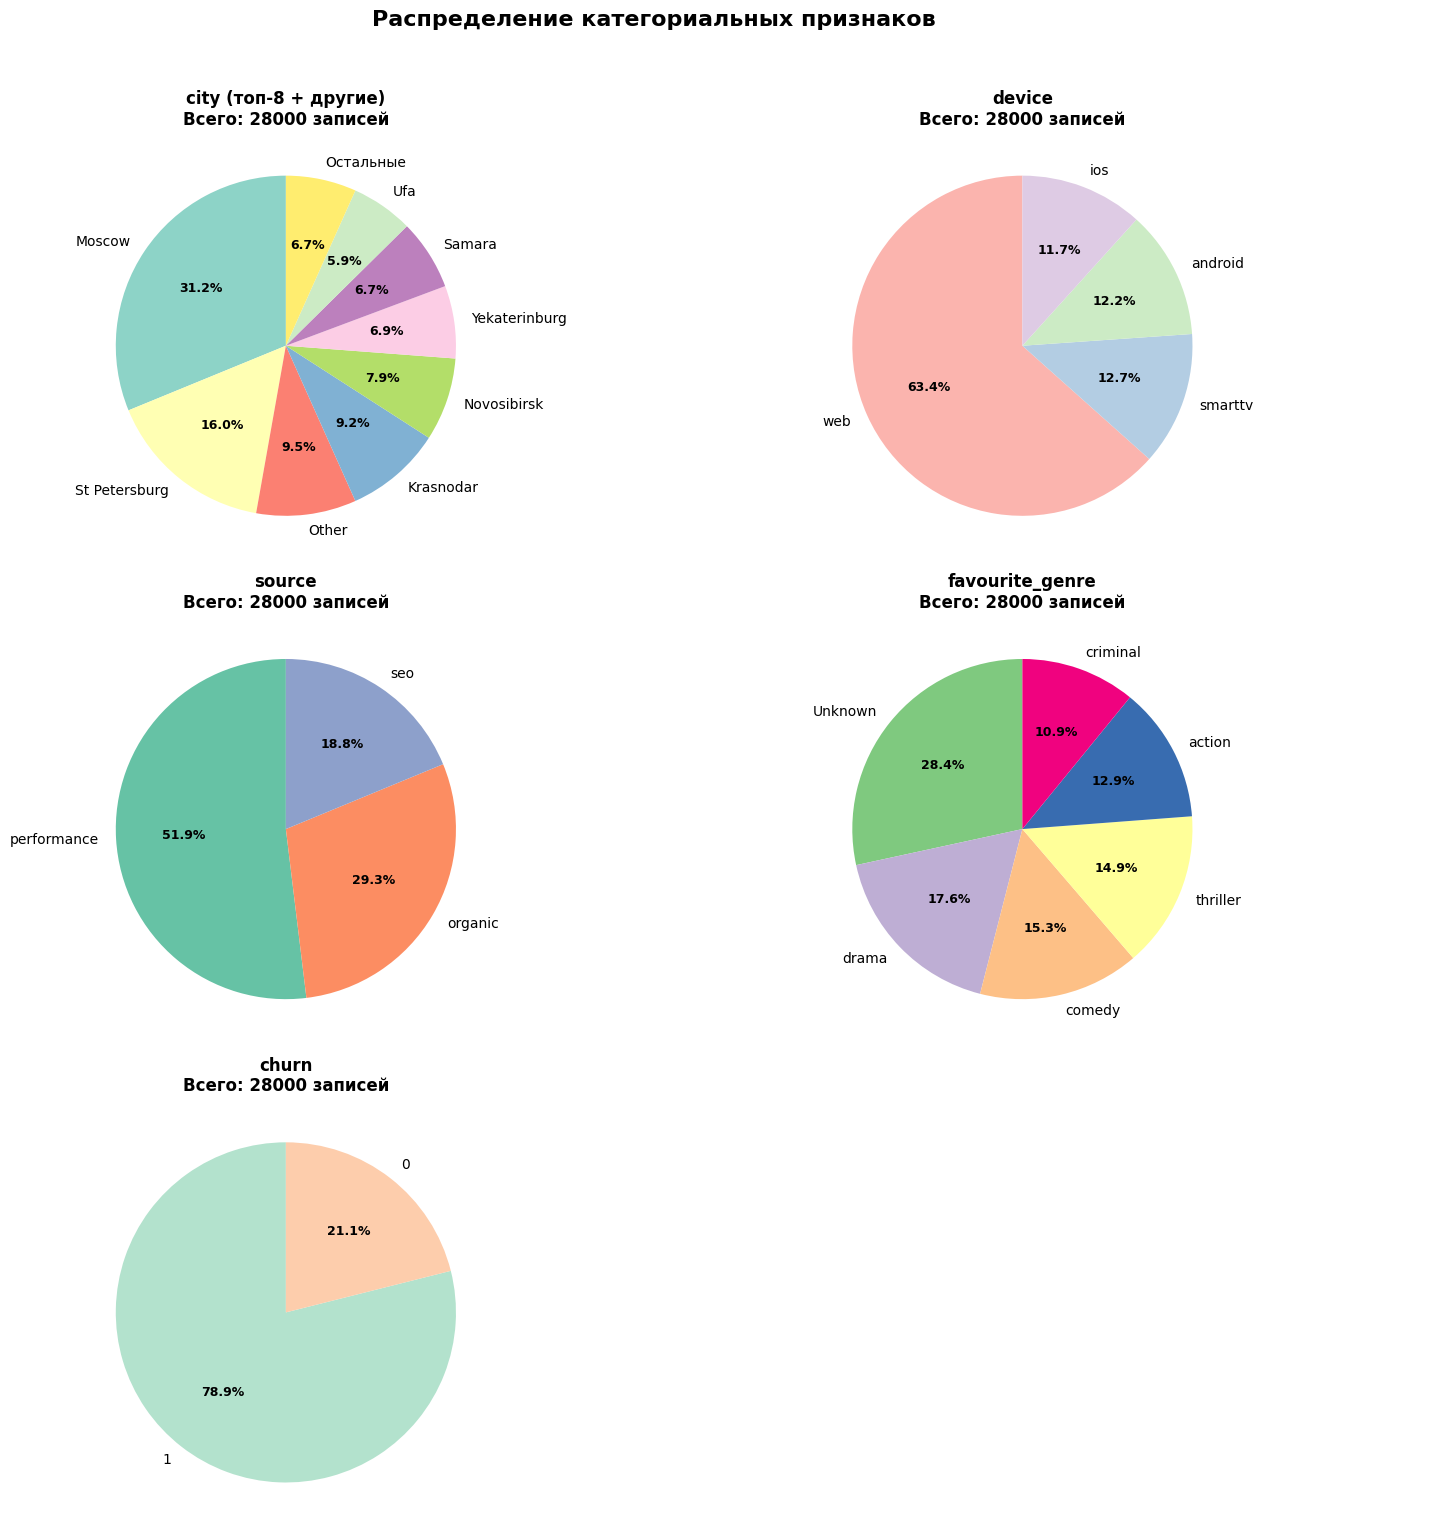

In [13]:
# Определяем категориальные признаки
categorical_columns = ['city', 'device', 'source', 'favourite_genre', 'churn']

fig, axes = plt.subplots(3, 2, figsize=(16, 15))
axes = axes.flatten()

color_palettes = [
    plt.cm.Set3,
    plt.cm.Pastel1,
    plt.cm.Set2,
    plt.cm.Accent,
    plt.cm.Pastel2
]

for i, col in enumerate(categorical_columns):
    if i < len(axes):
        ax = axes[i]

        # Получаем данные
        value_counts = df[col].value_counts()
        total = len(df[col])

        # Если уникальных значений много, показываем топ-8
        if len(value_counts) > 8:
            top_values = value_counts.head(8)
            others_count = value_counts[8:].sum()
            if others_count > 0:
                top_values['Остальные'] = others_count
            title_suffix = " (топ-8 + другие)"
        else:
            top_values = value_counts
            title_suffix = ""

        n_colors = len(top_values)
        if i < len(color_palettes):
            colors = color_palettes[i](np.linspace(0, 1, max(n_colors, 8)))
        else:
            colors = plt.cm.tab20c(np.linspace(0, 1, n_colors))

        colors = colors[:n_colors]

        wedges, texts, autotexts = ax.pie(top_values.values,
                                          labels=top_values.index.astype(str),
                                          autopct='%1.1f%%',
                                          startangle=90,
                                          colors=colors)

        ax.set_title(f'{col}{title_suffix}\nВсего: {total} записей',
                    fontsize=12, fontweight='bold')

        for autotext in autotexts:
            autotext.set_color('black')
            autotext.set_fontsize(9)
            autotext.set_fontweight('bold')

for i in range(len(categorical_columns), len(axes)):
    axes[i].axis('off')

plt.suptitle('Распределение категориальных признаков', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Все данные выглядят адекватно**

# Построение диаграмм числовых признаков для анализа распределение данных

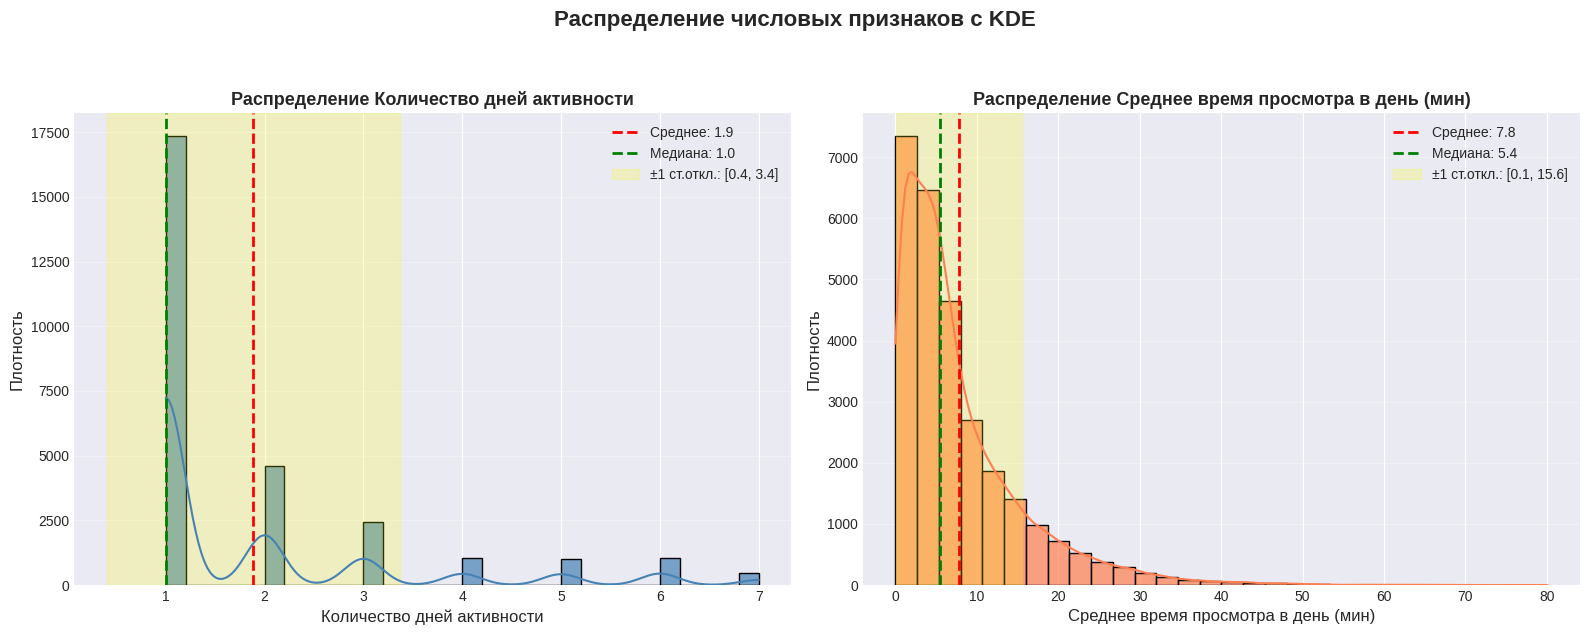


number_of_days_logged:

Асимметрия: 1.854 (сильно скошенное)
Эксцесс: 2.616

avg_min_watch_daily:

Асимметрия: 2.020 (сильно скошенное)
Эксцесс: 5.693


In [14]:
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Распределение числовых признаков с KDE', fontsize=16, fontweight='bold', y=1.05)

numeric_features = ['number_of_days_logged', 'avg_min_watch_daily']

colors = ['steelblue', 'coral']

for idx, (feature, color) in enumerate(zip(numeric_features, colors)):
    ax = axes[idx]

    sns.histplot(data=df, x=feature, bins=30,
                 kde=True, color=color, edgecolor='black', alpha=0.7, ax=ax)

    mean_val = df[feature].mean()
    median_val = df[feature].median()
    std_val = df[feature].std()

    feature_names = {
        'number_of_days_logged': 'Количество дней активности',
        'avg_min_watch_daily': 'Среднее время просмотра в день (мин)'
    }

    feature_name = feature_names.get(feature, feature)
    ax.set_title(f'Распределение {feature_name}', fontsize=13, fontweight='bold')
    ax.set_xlabel(feature_name, fontsize=12)
    ax.set_ylabel('Плотность', fontsize=12)

    # Добавляем линии для среднего и медианы
    ax.axvline(mean_val, color='red', linestyle='--', linewidth=2,
               label=f'Среднее: {mean_val:.1f}')
    ax.axvline(median_val, color='green', linestyle='--', linewidth=2,
               label=f'Медиана: {median_val:.1f}')

    # Добавляем область ±1 стандартное отклонение
    ax.axvspan(mean_val - std_val, mean_val + std_val, alpha=0.2, color='yellow',
               label=f'±1 ст.откл.: [{mean_val-std_val:.1f}, {mean_val+std_val:.1f}]')

    ax.legend(loc='upper right', fontsize=10)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

for feature in numeric_features:
    print(f"\n{feature}:\n")

    # Асимметрия и эксцесс
    skewness = df[feature].skew()
    kurtosis = df[feature].kurtosis()

    skewness_interpretation = "симметричное" if abs(skewness) < 0.5 else \
                             "умеренно скошенное" if abs(skewness) < 1 else \
                             "сильно скошенное"

    print(f"Асимметрия: {skewness:.3f} ({skewness_interpretation})")
    print(f"Эксцесс: {kurtosis:.3f}")


**Все данные выглядят адекватно**

# Построение тепловой диаграммы, чтобы найти линейные зависимости между признаками

In [15]:
# Сначала сделаем one-hot преобразование категориальных признаков
categorical_cols = ['city', 'device', 'source', 'favourite_genre']
data_encoded = pd.get_dummies(df, columns=categorical_cols)

print(data_encoded.head())

                                user_id start_trial_date  avg_min_watch_daily  \
0  d1b6ef34-1991-452a-8c39-c83c0d5805fe       2024-02-01             2.076642   
1  f1bf2396-73d8-461e-a775-9f068bd99326       2024-02-01             5.101392   
2  ec9fa0be-4bd8-4fe6-910a-e9e6d4bbba28       2024-02-01             2.906597   
3  b0195e96-af2e-4ac3-8f60-26b8d862af84       2024-02-01             2.702388   
4  a208985a-7244-4291-8d38-64c8141e27b2       2024-02-01            10.237305   

   number_of_days_logged  churn  trial_start_day_of_week  city_Krasnodar  \
0                      4      1                        3           False   
1                      1      1                        3           False   
2                      1      1                        3           False   
3                      6      0                        3           False   
4                      1      1                        3           False   

   city_Moscow  city_Novosibirsk  city_Other  ...  devic

In [16]:
# Удалим колонку 'user_id', чтобы не мешала анализу
del data_encoded['user_id']

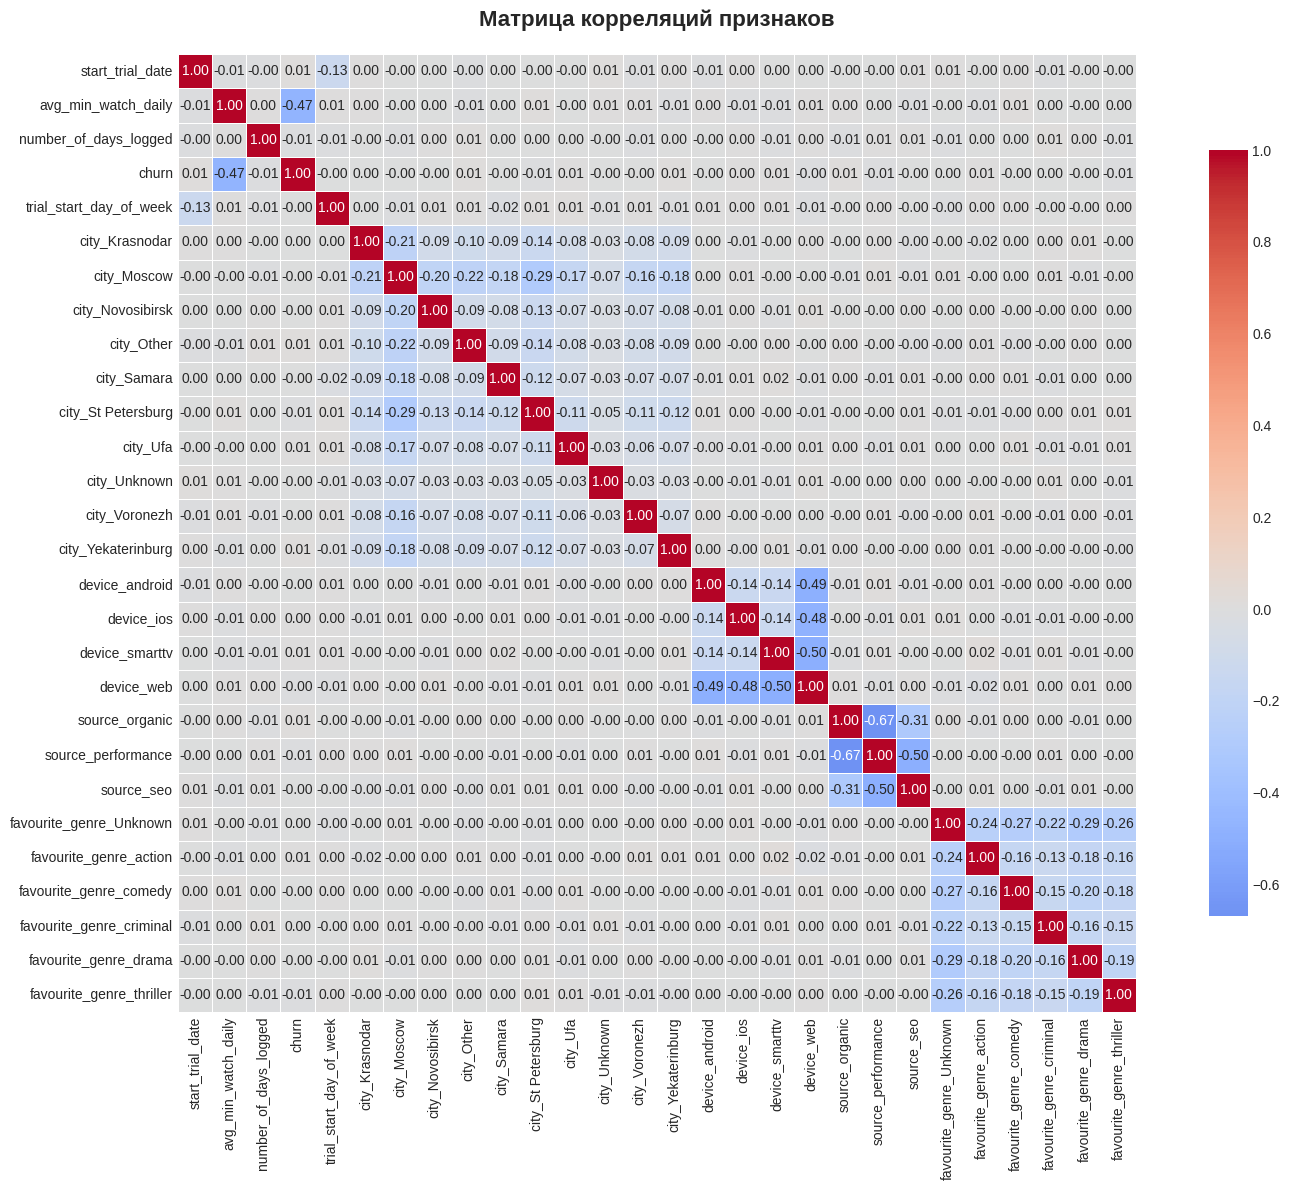

In [17]:
# Строим тепловую диаграмму
correlation_matrix = data_encoded.corr()

plt.figure(figsize=(16, 12))
sns.heatmap(correlation_matrix,
            annot=True,
            fmt=".2f",
            cmap="coolwarm",
            center=0,
            square=True,
            linewidths=0.5,
            cbar_kws={"shrink": 0.8})

plt.title("Матрица корреляций признаков", fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

Наблюдается **отрицательная корреляция** между **churn** и **avg_min_watch_daily** (-0.47) - чем больше время просмотров в день, тем меньше вероятность ухода

## Гипотеза 0. Какие либо признаки (город, устройство, источник, любимый жанр) связаны с оттоком пользователей.

### Стратегия проверки
Для каждого one-hot столбца создать таблицу сопряженности 2×2 с churn
Рассчитать коэффициент фи (φ) для измерения силы и направления связи
Рассчитать p-value через тест хи-квадрат для проверки значимости

### Статистический метод

Тест хи-квадрат Пирсона для независимости с последующим расчетом коэффициента фи (φ)

#### Обоснование выбора теста:

Природа данных определяет метод:
 - Целевая переменная churn — бинарная (0 или 1, продлил/отписался)
 - Признаки — категориальные, преобразованные в one-hot (город, устройство, источник, жанр)

Хи-квадрат — стандартный тест для категориальных данных:
Проверяет независимость двух категориальных переменных.
Не требует предположений о нормальности распределения.

Коэффициент фи (φ) дополняет хи-квадрат:
Хи-квадрат показывает «есть ли связь» (p-value).
φ показывает «насколько сильна связь» (величина эффекта) и «в какую сторону» (знак).



# Проверка гипотезы статистическими тестами

### H₀: Категориальные признаки (город, устройство, источник, любимый жанр) не связаны с оттоком пользователей. P(churn=1 | X=1) = P(churn=1 | X=0)
### H₁: Существует статистически значимая связь между хотя бы одним категориальным признаком и оттоком. P(churn=1 | X=1) ≠ P(churn=1 | X=0)

In [18]:
from scipy.stats import chi2_contingency

results = []

for col in data_encoded.columns:
    if any(cat in col for cat in ['city_', 'device_', 'source_', 'favourite_genre_']):
        conf_matrix = pd.crosstab(data_encoded[col], data_encoded['churn'])

        # Фи-коэффициент для 2x2 таблицы
        if conf_matrix.shape == (2, 2):
            a, b, c, d = conf_matrix.values.flatten()
            phi = (a*d - b*c) / np.sqrt((a+b)*(c+d)*(a+c)*(b+d))
        else:
            # V Крамера для таблиц больше 2x2
            chi2 = chi2_contingency(conf_matrix)[0]
            n = conf_matrix.sum().sum()
            phi = np.sqrt(chi2 / n)

        # p-value для проверки значимости
        _, p_value, _, _ = chi2_contingency(conf_matrix)

        results.append({
            'feature': col,
            'phi_coefficient': round(phi, 4),
            'p_value': round(p_value, 6),
            'significant': p_value < 0.05
        })

phi_results = pd.DataFrame(results)
phi_results = phi_results.sort_values('phi_coefficient', key=abs, ascending=False)

print("Связь категориальных признаков с оттоком:")
print(phi_results[['feature', 'phi_coefficient', 'p_value', 'significant']])

Связь категориальных признаков с оттоком:
                     feature  phi_coefficient   p_value  significant
9         city_Yekaterinburg           0.0114  0.059451        False
5         city_St Petersburg          -0.0100  0.097147        False
14            source_organic           0.0099  0.099254        False
3                 city_Other           0.0091  0.133793        False
15        source_performance          -0.0083  0.170648        False
6                   city_Ufa           0.0078  0.200138        False
18    favourite_genre_action           0.0066  0.282176        False
12            device_smarttv           0.0064  0.294901        False
22  favourite_genre_thriller          -0.0056  0.356622        False
13                device_web          -0.0044  0.467190        False
1                city_Moscow          -0.0040  0.512648        False
4                city_Samara          -0.0034  0.589735        False
21     favourite_genre_drama          -0.0029  0.641495      

### Выводы: Статистически значимых связей категориальных переменных с целевой нет

# Проанализируем как отток меняется в зависимости от среднего времени просмотра в день.

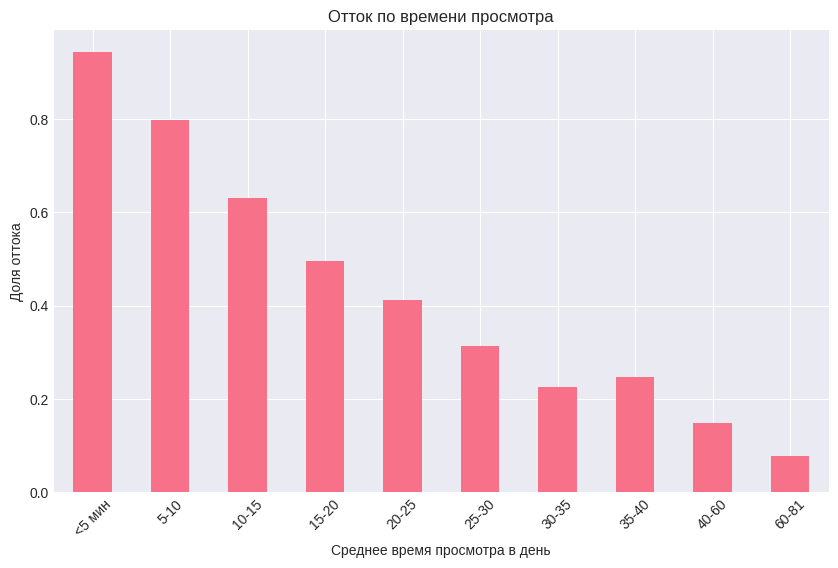

In [19]:
bins_minutes = [0, 5, 10, 15, 20, 25, 30, 35, 40, 60, 81]
labels = ['<5 мин', '5-10', '10-15', '15-20', '20-25', '25-30', '30-35', '35-40', '40-60', '60-81']

df['watch_category'] = pd.cut(df['avg_min_watch_daily'],
                               bins=bins_minutes,
                               labels=labels,
                               right=False)

df.groupby('watch_category')['churn'].mean().plot(kind='bar', figsize=(10, 6))

plt.title('Отток по времени просмотра')
plt.ylabel('Доля оттока')
plt.xlabel('Среднее время просмотра в день')
plt.xticks(rotation=45)
plt.show()

## Гипотеза 1: Среднее время просмотра влияет на покупку

Чем выше среднее время просмотра в день, тем выше конверсия в подписку.

### Стратегия проверки

Разобьем на две группы:

1. те, кто совершил подписку
2. те, кто нет

Проверим, различаются ли статистически у них среднее время просмотра.

### Статистический метод

Тест Манна-Уитни

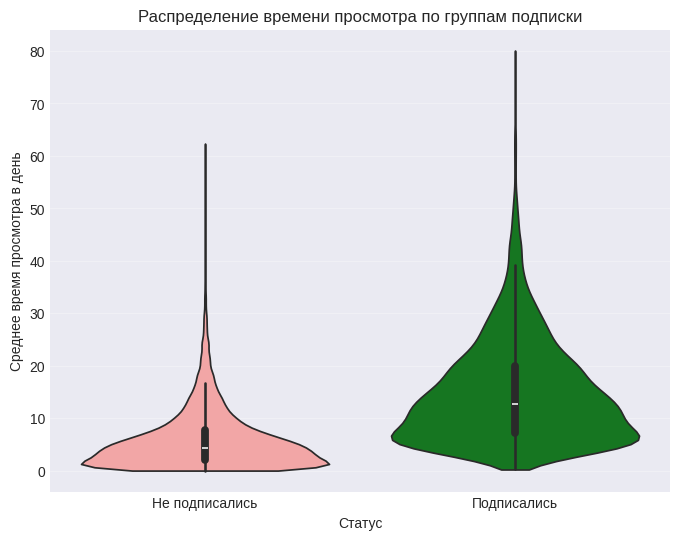

In [20]:
plt.figure(figsize=(8, 6))

df_sorted = df.copy()
df_sorted["churn_str"] = df_sorted["churn"].map({1: "Не подписались", 0: "Подписались"})

sns.violinplot(
    data=df_sorted,
    x="churn_str",
    y="avg_min_watch_daily",
    palette=["#ff9999", "#068615"],
    cut=0
)

plt.title("Распределение времени просмотра по группам подписки")
plt.xlabel("Статус")
plt.ylabel("Среднее время просмотра в день")
plt.grid(axis="y", alpha=0.3)

plt.show()


Взяли Манна-Уитни, так как у нас ненормальное распределение среднего времени просмотра.


H₀ (нулевая гипотеза): медианное (или среднее) время просмотра у подписавшихся не больше, чем у отписавшихся.

H₁ (альтернативная гипотеза): медианное время просмотра у подписавшихся больше, чем у отписавшихся.

In [21]:
df["converted"] = (df["churn"] == 0).astype(int)
group_buy = df[df["converted"] == 1]["avg_min_watch_daily"]
group_not = df[df["converted"] == 0]["avg_min_watch_daily"]


In [22]:
x = group_buy.values
y = group_not.values

median_buy = np.median(x)
median_not = np.median(y)
# ранги
all_vals = np.concatenate([x, y])
ranks = np.argsort(np.argsort(all_vals)) + 1

# ранги обратно в группы
r_x = ranks[:len(x)]
r_y = ranks[len(x):]

# U-статистика
U1 = r_x.sum() - len(x)*(len(x)-1)/2
U2 = r_y.sum() - len(y)*(len(y)-1)/2
U = min(U1, U2)

# мат. ожидание и дисперсия
mu = len(x)*len(y)/2
sigma = np.sqrt(len(x)*len(y)*(len(x)+len(y)+1)/12)

# Z-оценка
Z = (U - mu) / sigma

# p-value через нормальное распределение
from math import erf, sqrt
p_value = 2 * (1 - 0.5 * (1 + erf(abs(Z) / sqrt(2))))

print("Результаты теста Манна–Уитни на различие среднего времени просмотра\n")
print(f"Медианное время просмотра (подписались): {median_buy:.2f} мин/день")
print(f"Медианное время просмотра (не подписались): {median_not:.2f} мин/день\n")
print(f"U-статистика: {U:.2f}")
print(f"Z-значение: {Z:.2f}")
print(f"p-value: {p_value:.3g}\n")

if p_value < 0.05:
    print("Вывод: различия статистически значимы (p < 0.05).**")
    if median_buy > median_not:
        print("Пользователи, которые подписались, смотрели существенно больше.")
    else:
        print("Не подписавшиеся смотрели больше (что маловероятно для такой задачи).")
else:
    print("Вывод: статистически значимых различий НЕ обнаружено.")

print("\nИнтерпретация:")
print("Чем больше пользователь смотрит в триал, тем выше вероятность, что он купит подписку.")
print("Этот признак — сильный маркер вовлечённости и должен использоваться в модели.")

Результаты теста Манна–Уитни на различие среднего времени просмотра

Медианное время просмотра (подписались): 12.62 мин/день
Медианное время просмотра (не подписались): 4.38 мин/день

U-статистика: 23617448.00
Z-значение: -75.38
p-value: 0

Вывод: различия статистически значимы (p < 0.05).**
Пользователи, которые подписались, смотрели существенно больше.

Интерпретация:
Чем больше пользователь смотрит в триал, тем выше вероятность, что он купит подписку.
Этот признак — сильный маркер вовлечённости и должен использоваться в модели.


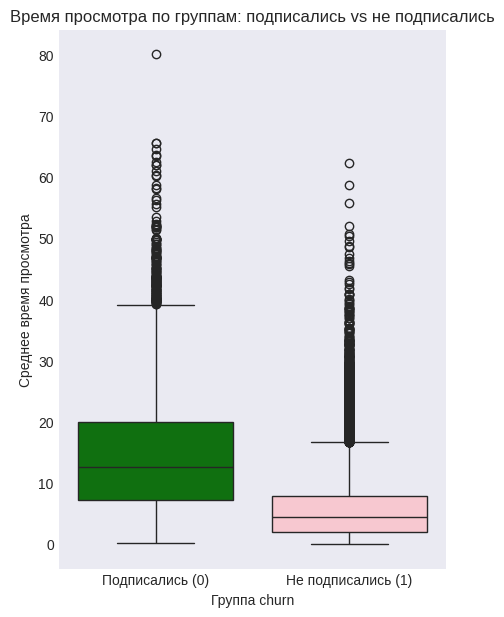

In [23]:
plt.figure(figsize=(5, 7))
sns.boxplot(
    data=df,
    x="churn",
    y="avg_min_watch_daily",
    palette={"0": "green", "1": "pink"}
)

plt.xticks([0, 1], ["Подписались (0)", "Не подписались (1)"])
plt.title("Время просмотра по группам: подписались vs не подписались")
plt.xlabel("Группа churn")
plt.ylabel("Среднее время просмотра")
plt.grid(axis='y')

plt.show()


**Гипотеза 1 подтверждена. Пользователи с более высоким средним временем просмотра значительно чаще покупают подписку.**

Разница по Манна–Уитни: Z = –75.4, p < 0.001

Это означает, что распределения существенно различаются.

Глубина просмотра - важдый маркер конверсии.


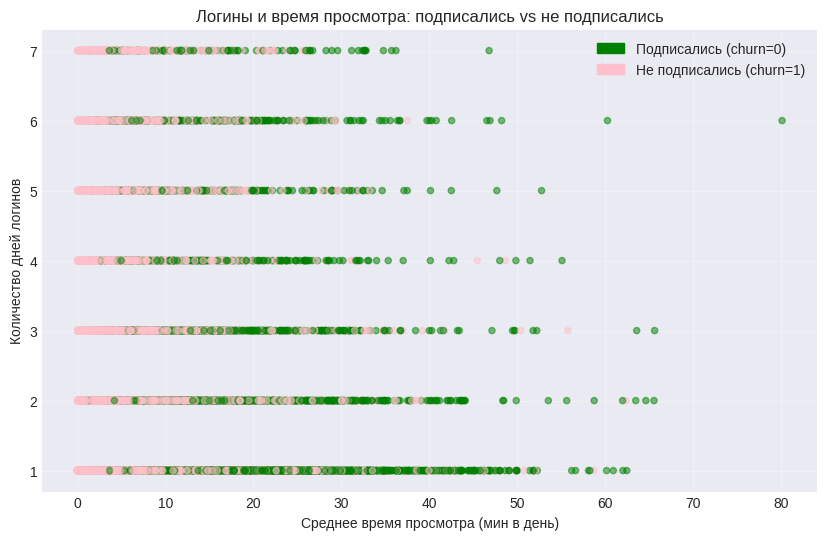

In [24]:
colors = df["churn"].map({0: "green", 1: "pink"})

plt.figure(figsize=(10, 6))

plt.scatter(
    df["avg_min_watch_daily"],
    df["number_of_days_logged"],
    c=colors,
    alpha=0.5,
    s=20,
)

plt.xlabel("Среднее время просмотра (мин в день)")
plt.ylabel("Количество дней логинов")
plt.title("Логины и время просмотра: подписались vs не подписались")

import matplotlib.patches as mpatches
green_patch = mpatches.Patch(color='green', label='Подписались (churn=0)')
pink_patch  = mpatches.Patch(color='pink', label='Не подписались (churn=1)')
plt.legend(handles=[green_patch, pink_patch])

plt.grid(True, alpha=0.3)
plt.show()

Даже если пользователь заходил 1-2 но смотрел больше 10-20 минут вероятность подписку выше, чес у тех кто был в сервисе меньше 10 минут;

С дрегой строны даже 7 дней подключений, не гарантируют подключение платной подписки, там так же есть большое количество отписавшихся среди тех кто смотрел меньше 10 дней.

Посмотрим дальше насколько это достоверно.

### Двухфакторный анализ — метод множественной логистической регрессии
Проверяем, является ли avg_min_watch_daily значимым предиктором после учёта number_of_days_logged.

Логистическая регрессия проверяет значимость коэффициентов.Поэтому нулевая и альтернативная гипотезы следующие:

*Для переменной avg_min_watch_daily:*

H0: avg_min_watch_daily не влияет на отток

H1: avg_min_watch_daily влияет на отток


*Для переменной number_of_days_logged:*

H0: number_of_days_logged не влияет на отток

H1: number_of_days_logged влияет на отток

In [25]:
df2 = df[["avg_min_watch_daily", "number_of_days_logged", "churn"]].copy()
X = df2[["avg_min_watch_daily", "number_of_days_logged"]]
X = sm.add_constant(X)
y = df2["churn"]

model = sm.Logit(y, X).fit()
print(model.summary())

Optimization terminated successfully.
         Current function value: 0.413362
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                  churn   No. Observations:                28000
Model:                          Logit   Df Residuals:                    27997
Method:                           MLE   Df Model:                            2
Date:                Wed, 17 Dec 2025   Pseudo R-squ.:                  0.1972
Time:                        18:11:43   Log-Likelihood:                -11574.
converged:                       True   LL-Null:                       -14417.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                     2.7548      0.036     77.005      0.000       2.685       2.

In [26]:
coef_watch = model.params["avg_min_watch_daily"]
coef_days = model.params["number_of_days_logged"]
coef_watch

np.float64(-0.1489424060693088)

**Посчитаем как влияет дополнительная минута просмотра и дополнительный день входа на конверсию в подписку**


In [27]:
coef_watch = model.params["avg_min_watch_daily"]
coef_days = model.params["number_of_days_logged"]

p_days = model.pvalues["avg_min_watch_daily"]
p_days = model.pvalues["number_of_days_logged"]


or_watch = np.exp(coef_watch)
or_days = np.exp(coef_days)

effect_watch = (1 - or_watch) * 100
effect_days = (1 - or_days) * 100

print("Интерпретация логистической регрессии")

print(f"Коэффициент avg_min_watch_daily = {coef_watch:.4f}")
print(f"P-value для времени просмотра: {p_days:.4f}")
print(f"Odds ratio = {or_watch:.4f}")
print(f"Каждая дополнительная минута просмотра снижает шансы отписки на {effect_watch:.2f}%\n")

print(f"Коэффициент number_of_days_logged = {coef_days:.4f}")
print(f"P-value для числа дней логинов: {p_days:.4f}")
print(f"Odds ratio = {or_days:.4f}")
print(f"Каждый дополнительный день логина снижает шансы отписки на {effect_days:.2f}%")

Интерпретация логистической регрессии
Коэффициент avg_min_watch_daily = -0.1489
P-value для времени просмотра: 0.0352
Odds ratio = 0.8616
Каждая дополнительная минута просмотра снижает шансы отписки на 13.84%

Коэффициент number_of_days_logged = -0.0233
P-value для числа дней логинов: 0.0352
Odds ratio = 0.9769
Каждый дополнительный день логина снижает шансы отписки на 2.31%


Ключевым драйвером покупки подписки является не просто факт захода в сервис, а глубина просмотра контента.

Нужно сосредоточиться на времени удержания клиента, например лучше настроить систему рекомендаций.

Или с другой стороны сделать какую-то модель которая будет предсказывать холодных клиентов которые смотрят до 5-10 минут в день и не тратить на них рекламные бюджеты.

# Проанализируем какое минимальное время просмотра защищает от оттока

In [28]:
# Анализ пороговых значений для времени просмотра
threshold_analysis = []
for threshold in [5, 10, 15, 30, 60]:
    churn_below = df[df['avg_min_watch_daily'] < threshold]['churn'].mean()
    churn_above = df[df['avg_min_watch_daily'] >= threshold]['churn'].mean()
    threshold_analysis.append({
        'threshold': threshold,
        'churn_below': churn_below,
        'churn_above': churn_above,
        'diff': churn_below - churn_above
    })

threshold_df = pd.DataFrame(threshold_analysis)
print("\nАнализ порогов для времени просмотра:")
print(threshold_df)


Анализ порогов для времени просмотра:
   threshold  churn_below  churn_above      diff
0          5     0.944513     0.654175  0.290338
1         10     0.891101     0.508850  0.382252
2         15     0.853723     0.405466  0.448257
3         30     0.802102     0.205980  0.596122
4         60     0.789617     0.076923  0.712694


# Построение графика, демонстрирующего пороговое значение

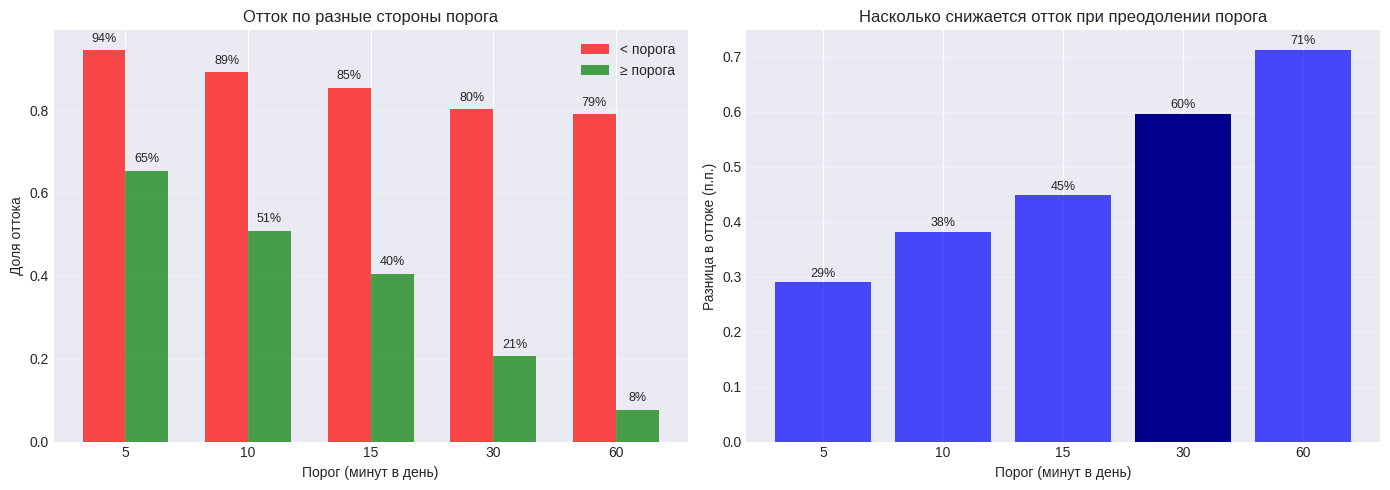

In [29]:
# Данные из анализа
thresholds = [5, 10, 15, 30, 60]
churn_below = [0.945, 0.891, 0.854, 0.802, 0.790]
churn_above = [0.654, 0.509, 0.405, 0.206, 0.077]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# График 1: Отток по обе стороны порога
x = np.arange(len(thresholds))
width = 0.35

ax1.bar(x - width/2, churn_below, width, label='< порога', color='red', alpha=0.7)
ax1.bar(x + width/2, churn_above, width, label='≥ порога', color='green', alpha=0.7)
ax1.set_xlabel('Порог (минут в день)')
ax1.set_ylabel('Доля оттока')
ax1.set_title('Отток по разные стороны порога')
ax1.set_xticks(x)
ax1.set_xticklabels(thresholds)
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Подписи значений к графику 1
for i, (cb, ca) in enumerate(zip(churn_below, churn_above)):
    ax1.text(i - width/2, cb + 0.02, f'{cb:.0%}', ha='center', fontsize=9)
    ax1.text(i + width/2, ca + 0.02, f'{ca:.0%}', ha='center', fontsize=9)

# График 2: Выигрыш от преодоления порога
ax2.bar(x, threshold_df['diff'], color='blue', alpha=0.7)
ax2.set_xlabel('Порог (минут в день)')
ax2.set_ylabel('Разница в оттоке (п.п.)')
ax2.set_title('Насколько снижается отток при преодолении порога')
ax2.set_xticks(x)
ax2.set_xticklabels(thresholds)
ax2.grid(axis='y', alpha=0.3)

# Выделение порога 30 минут
ax2.bar(3, threshold_df.loc[3, 'diff'], color='darkblue')

# Подписи значений к графику 2
for i, diff in enumerate(threshold_df['diff']):
    ax2.text(i, diff + 0.01, f'{diff:.0%}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

## Гипотеза 2. Порог ценности в 30 минут просмотра влияет на вероятность оттока

Порог 30 мин. Пользователи кто смотрит < 30 минут уходит в 80% случаев (не видит ценности), кто более 30 минут уходит в 20% случаев (видит ценность, возможно смотрит какой-то конкретный контент).

### Стратегия проверки

Разделим пользователей на 2 группы:
1. пользователи с avg_min_watch_daily < 30 минут
2. пользователи с avg_min_watch_daily ≥ 30 минут.

Проверим, различается ли статистически доля оттока в каждой группе.

### Статистический метод

Z-тест для пропорций (основной метод) и доверительные интервалы.

#### Обоснование выбора теста:

Для долей/пропорций работает Центральная Предельная Теорема (ЦПТ):
Выборка достаточно большая (n > 30).
Распределение выборочной доли стремится к нормальному.
Не требуется нормальность исходных данных

# Проверка гипотезы статистическими тестами

### H₀: Время просмотра не влияет на решение о покупке подписки. Доли оттока равны.
### H₁: Доля оттока в группе с просмотром <30 минут БОЛЬШЕ, чем в группе с просмотром ≥30 минут.

In [30]:
from statsmodels.stats.proportion import proportions_ztest

# Проверяем порог 30 минут
below_30 = df[df['avg_min_watch_daily'] < 30]
above_30 = df[df['avg_min_watch_daily'] >= 30]

counts = [below_30['churn'].sum(), above_30['churn'].sum()]
nobs = [len(below_30), len(above_30)]

z_stat, p_value = proportions_ztest(counts, nobs, alternative='larger')
print(f"\nСтатистическая проверка порога 30 минут:")
print(f"Z-статистика: {z_stat:.2f}")
print(f"p-value: {p_value:.10f}")

if p_value < 0.0001:
    print("Разница чрезвычайно статистически значима (p < 0.0001)")

# Относительный риск
rr = below_30['churn'].mean() / above_30['churn'].mean()
print(f"\nОтносительный риск: {rr:.1f}")
print(f"Риск оттока при <30 мин в {rr:.1f} раза выше")


Статистическая проверка порога 30 минут:
Z-статистика: 35.48
p-value: 0.0000000000
Разница чрезвычайно статистически значима (p < 0.0001)

Относительный риск: 3.9
Риск оттока при <30 мин в 3.9 раза выше


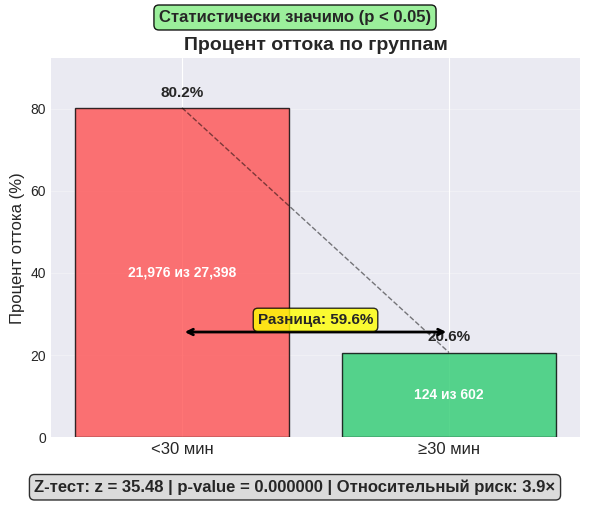

In [31]:
# Рассчитываем проценты
p1 = counts[0] / nobs[0]  # доля оттока в группе <30 мин
p2 = counts[1] / nobs[1]  # доля оттока в группе ≥30 мин


fig, ax2 = plt.subplots(1, 1, figsize=(6, 5))

x_pos = [0, 1]
group_names = ['<30 мин', '≥30 мин']
colors_samples = ['#FF6B6B', '#4ECDC4']
# Проценты оттока
percentages = [p1 * 100, p2 * 100]  # в процентах
colors_churn = ['#FF5252', '#2ECC71']

bars2 = ax2.bar(x_pos, percentages, color=colors_churn, alpha=0.8, edgecolor='black')

ax2.set_title('Процент оттока по группам', fontsize=14, fontweight='bold')
ax2.set_ylabel('Процент оттока (%)', fontsize=12)
ax2.set_xticks(x_pos)
ax2.set_xticklabels(group_names, fontsize=12)
ax2.set_ylim(0, max(percentages) * 1.15)
ax2.grid(axis='y', alpha=0.3)

# Подписи над столбиками
for i, bar in enumerate(bars2):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 2,
            f'{height:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

    # Абсолютные числа в оттоке
    ax2.text(bar.get_x() + bar.get_width()/2., height/2,
            f'{counts[i]:,} из {nobs[i]:,}', ha='center', va='center',
            fontsize=10, color='white', fontweight='bold')

# Линия сравнения и стрелка
diff = p1 - p2
ax2.plot([0, 1], [percentages[0], percentages[1]], 'k--', alpha=0.5, linewidth=1)
ax2.annotate('', xy=(1, percentages[1] + 5), xytext=(0, percentages[1] + 5),
            arrowprops=dict(arrowstyle='<->', color='black', lw=2))
ax2.text(0.5, percentages[1] + 7, f'Разница: {diff*100:.1f}%',
         ha='center', fontsize=11, fontweight='bold',
         bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.8))

# p-value и статистика на графике
plt.figtext(0.5, 0.01,
           f'Z-тест: z = {z_stat:.2f} | p-value = {p_value:.6f} | '
           f'Относительный риск: {p1/p2:.1f}×',
           ha='center', fontsize=12, fontweight='bold',
           bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.8))

# Цветовая индикация значимости
if p_value < 0.05:
    significance_box = dict(boxstyle='round', facecolor='lightgreen', alpha=0.9)
    significance_text = 'Статистически значимо (p < 0.05)'
else:
    significance_box = dict(boxstyle='round', facecolor='lightcoral', alpha=0.9)
    significance_text = 'Не значимо (p ≥ 0.05)'

plt.figtext(0.5, 0.95, significance_text,
           ha='center', fontsize=12, fontweight='bold',
           bbox=significance_box)

plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()


# Построение доверительных интервалов

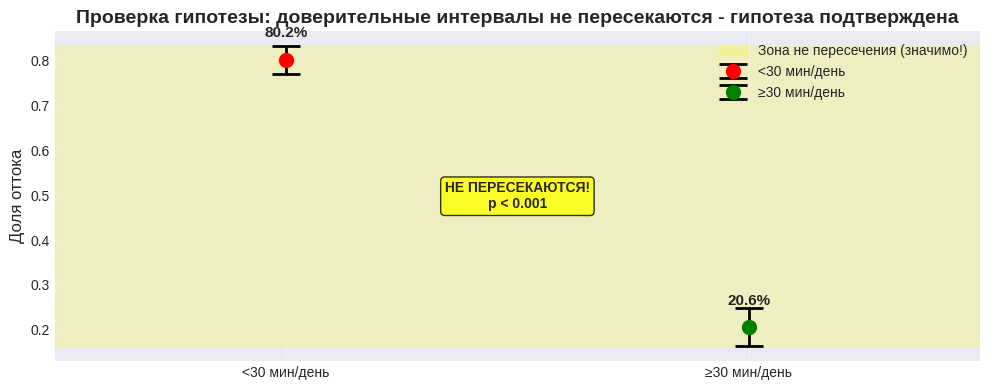

In [32]:
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.stats.proportion import proportion_confint

# Данные
p_below = 0.802  # 80.2% оттока
p_above = 0.206  # 20.6% оттока
n_below, n_above = 650, 350

# Доверительные интервалы 95%
ci_below = proportion_confint(count=int(p_below*n_below), nobs=n_below, alpha=0.05)
ci_above = proportion_confint(count=int(p_above*n_above), nobs=n_above, alpha=0.05)

fig, ax = plt.subplots(figsize=(10, 4))

# Первая точка (<30 мин) - крвсная
ax.errorbar(x=0, y=p_below,
            yerr=[[p_below - ci_below[0]], [ci_below[1] - p_below]],
            fmt='o', capsize=10, capthick=2, markersize=10,
            color='red', ecolor='black', linewidth=2, label='<30 мин/день')

# Вторая точка (≥30 мин) - зеленая
ax.errorbar(x=1, y=p_above,
            yerr=[[p_above - ci_above[0]], [ci_above[1] - p_above]],
            fmt='o', capsize=10, capthick=2, markersize=10,
            color='green', ecolor='black', linewidth=2, label='≥30 мин/день')

ax.set_xlim(-0.5, 1.5)
ax.set_xticks([0, 1])
ax.set_xticklabels(['<30 мин/день', '≥30 мин/день'])
ax.set_ylabel('Доля оттока', fontsize=12)
ax.set_title('Проверка гипотезы: доверительные интервалы не пересекаются - гипотеза подтверждена',
             fontsize=14, fontweight='bold')

# Добавляем значения
ax.text(0, p_below + 0.05, f'{p_below:.1%}', ha='center', fontsize=11, fontweight='bold')
ax.text(1, p_above + 0.05, f'{p_above:.1%}', ha='center', fontsize=11, fontweight='bold')

# Линия значимости
if ci_below[1] > ci_above[0]:
    ax.axhspan(ci_below[1], ci_above[0], alpha=0.2, color='yellow',
               label='Зона не пересечения (значимо!)')
    ax.text(0.5, (ci_below[1] + ci_above[0])/2, 'НЕ ПЕРЕСЕКАЮТСЯ!\np < 0.001',
            ha='center', va='center', fontsize=10, fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.8))

ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

### Выводы: Разница в оттоке между группами (<30 мин: 80.2%, ≥30 мин: 20.6%) является статистически высокозначимой (p < 0.0001), что позволяет с уверенностью утверждать, что время просмотра является ключевым фактором оттока.

### Рекомендации: Сделать порог 30 минут ключевой метрикой для маркетинга и аналитики. Все усилия должны быть направлены на то, чтобы пользователь как можно быстрее достиг этого уровня.

In [33]:
import gradio as gr
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.stats.proportion import proportions_ztest, proportion_confint
import pandas as pd

def analyze_threshold(threshold_minutes, df):
    """
    Анализирует порог времени просмотра для оттока пользователей
    """
    # Разделяем данные по порогу
    below_threshold = df[df['avg_min_watch_daily'] < threshold_minutes]
    above_threshold = df[df['avg_min_watch_daily'] >= threshold_minutes]

    # Проверяем, есть ли данные в обеих группах
    if len(below_threshold) == 0 or len(above_threshold) == 0:
        error_msg = f"Ошибка: Одна из групп пуста при пороге {threshold_minutes} минут"
        return None, None, error_msg, "0", "0", "0", "0"

    # Подсчитываем статистики
    counts = [below_threshold['churn'].sum(), above_threshold['churn'].sum()]
    nobs = [len(below_threshold), len(above_threshold)]

    # Статистический тест
    try:
        z_stat, p_value = proportions_ztest(counts, nobs, alternative='larger')
    except Exception as e:
        return None, None, f"Ошибка в статистическом тесте: {str(e)}", "0", "0", "0", "0"

    # Рассчитываем проценты оттока
    p1 = counts[0] / nobs[0]  # Доля оттока в группе < порога
    p2 = counts[1] / nobs[1]  # Доля оттока в группе ≥ порога

    # Относительный риск
    rr = p1 / p2 if p2 > 0 else float('inf')

    # Доверительные интервалы (95%)
    ci_below = proportion_confint(count=counts[0], nobs=nobs[0], alpha=0.05)
    ci_above = proportion_confint(count=counts[1], nobs=nobs[1], alpha=0.05)

    # Создаем первый график - Процент оттока
    fig1, ax1 = plt.subplots(figsize=(10, 6))

    # Данные для графика
    percentages = [p1 * 100, p2 * 100]
    group_names = [f'< {threshold_minutes} мин', f'≥ {threshold_minutes} мин']
    colors_churn = ['#FF5252', '#2ECC71']

    # Создаем столбчатую диаграмму
    bars = ax1.bar([0, 1], percentages, color=colors_churn, alpha=0.8,
                   edgecolor='black', width=0.6)

    ax1.set_title(f'Процент оттока по группам (порог: {threshold_minutes} минут)',
                  fontsize=14, fontweight='bold')
    ax1.set_ylabel('Процент оттока (%)', fontsize=12)
    ax1.set_xlabel('Группы', fontsize=12)
    ax1.set_xticks([0, 1])
    ax1.set_xticklabels(group_names, fontsize=12)
    ax1.set_ylim(0, max(percentages) * 1.15)
    ax1.grid(axis='y', alpha=0.3)

    # Добавляем подписи над столбиками
    for i, bar in enumerate(bars):
        height = bar.get_height()
        # Процент
        ax1.text(bar.get_x() + bar.get_width()/2., height + 1,
                f'{height:.1f}%', ha='center', va='bottom',
                fontsize=11, fontweight='bold')
        # Абсолютные числа
        ax1.text(bar.get_x() + bar.get_width()/2., height/2,
                f'{counts[i]:,} из {nobs[i]:,}', ha='center', va='center',
                fontsize=10, color='white', fontweight='bold')

    # Линия сравнения и разница
    diff = p1 - p2
    ax1.plot([0, 1], [percentages[0], percentages[1]], 'k--',
             alpha=0.5, linewidth=1)
    ax1.text(0.5, max(percentages) * 1.05,
            f'Разница: {diff*100:.1f}%\nОтносительный риск: {rr:.1f}×',
            ha='center', fontsize=11, fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.8))

    # Информация о статистической значимости
    if p_value < 0.05:
        significance = 'Статистически значимо (p < 0.05)'
        sig_color = 'lightgreen'
    else:
        significance = 'Не статистически значимо (p ≥ 0.05)'
        sig_color = 'lightcoral'

    ax1.text(0.5, -max(percentages) * 0.15,
            f'{significance} | Z = {z_stat:.2f} | p-value = {p_value:.6f}',
            ha='center', fontsize=11, fontweight='bold',
            bbox=dict(boxstyle='round', facecolor=sig_color, alpha=0.8))

    plt.tight_layout()

    # Создаем второй график - Доверительные интервалы
    fig2, ax2 = plt.subplots(figsize=(10, 5))

    # Отображаем доверительные интервалы
    ax2.errorbar(x=0, y=p1,
                yerr=[[p1 - ci_below[0]], [ci_below[1] - p1]],
                fmt='o', capsize=10, capthick=2, markersize=10,
                color='red', ecolor='black', linewidth=2,
                label=f'< {threshold_minutes} мин')

    ax2.errorbar(x=1, y=p2,
                yerr=[[p2 - ci_above[0]], [ci_above[1] - p2]],
                fmt='o', capsize=10, capthick=2, markersize=10,
                color='green', ecolor='black', linewidth=2,
                label=f'≥ {threshold_minutes} мин')

    ax2.set_xlim(-0.5, 1.5)
    ax2.set_xticks([0, 1])
    ax2.set_xticklabels([f'< {threshold_minutes} мин', f'≥ {threshold_minutes} мин'],
                       fontsize=12)
    ax2.set_ylabel('Доля оттока', fontsize=12)
    ax2.set_title('Доверительные интервалы (95%) для долей оттока',
                  fontsize=14, fontweight='bold')

    # Добавляем значения процентов
    ax2.text(0, p1 + 0.02, f'{p1:.1%}', ha='center',
            fontsize=11, fontweight='bold')
    ax2.text(1, p2 + 0.02, f'{p2:.1%}', ha='center',
            fontsize=11, fontweight='bold')

    # Проверяем пересечение доверительных интервалов
    if ci_below[1] < ci_above[0] or ci_above[1] < ci_below[0]:
        ci_significance = "Доверительные интервалы НЕ пересекаются\n(статистически значимо)"
        ci_color = 'lightgreen'
    else:
        ci_significance = "Доверительные интервалы пересекаются\n(не статистически значимо)"
        ci_color = 'lightcoral'

    ax2.text(0.5, max(p1, p2) + 0.1, ci_significance,
            ha='center', fontsize=11, fontweight='bold',
            bbox=dict(boxstyle='round', facecolor=ci_color, alpha=0.8))

    ax2.grid(alpha=0.3)
    ax2.legend(fontsize=11)
    plt.tight_layout()

    # Формируем текстовый вывод
    stats_text = f"""
    ## Статистические результаты для порога {threshold_minutes} минут:

    ### Статистика групп:
    - **Группа < {threshold_minutes} мин:** {nobs[0]:,} пользователей, {counts[0]:,} отток ({p1:.1%})
    - **Группа ≥ {threshold_minutes} мин:** {nobs[1]:,} пользователей, {counts[1]:,} отток ({p2:.1%})

    ### Статистические тесты:
    - **Z-статистика:** {z_stat:.2f}
    - **p-value:** {p_value:.6f}

    ### Вывод:
    {significance}. {'Рекомендуем использовать этот порог для прогнозирования оттока.' if p_value < 0.05 else 'Порог не является статистически значимым для прогнозирования оттока.'}
    """

    return fig1, fig2, stats_text, str(z_stat), str(p_value), str(rr), significance

# Главная функция запуска
def launch_gradio_interface(df, initial_threshold=30):
    """
    Запускает Gradio интерфейс в Colab
    """
    print(f"Загружено {len(df):,} записей")

    # Находим разумные границы для слайдера
    min_time = int(max(1, df['avg_min_watch_daily'].min()))
    max_time = int(df['avg_min_watch_daily'].max())

    # Определяем оптимальные шаги для слайдера
    if max_time - min_time > 100:
        step = 5
    elif max_time - min_time > 50:
        step = 2
    else:
        step = 1

    # Создаем интерфейс
    with gr.Blocks(title="Анализ порога времени просмотра", theme=gr.themes.Soft()) as demo:
        gr.Markdown("# Анализ влияния времени просмотра на отток пользователей")
        gr.Markdown(f"**Всего данных:** {len(df):,} пользователей | **Общий отток:** {df['churn'].mean():.1%}")

        with gr.Row():
            with gr.Column(scale=1):
                gr.Markdown("### Настройки порога")
                threshold_slider = gr.Slider(
                    minimum=min_time,
                    maximum=max_time,
                    value=initial_threshold,
                    step=step,
                    label="Порог времени просмотра (минут)",
                    info=f"Диапазон: {min_time}-{max_time} мин"
                )

                # Быстрые кнопки для часто используемых значений
                gr.Markdown("### Быстрый выбор:")
                quick_buttons = gr.Row()
                with quick_buttons:
                    for value in [5, 10, 15, 30, 60]:
                        if min_time <= value <= max_time:
                            gr.Button(f"{value} мин", size="sm").click(
                                fn=lambda x=value: x,
                                outputs=threshold_slider
                            )

                gr.Markdown("### Ключевые метрики")
                z_stat_output = gr.Textbox(label="Z-статистика", interactive=False)
                p_value_output = gr.Textbox(label="p-value", interactive=False)
                rr_output = gr.Textbox(label="Относительный риск", interactive=False)
                significance_output = gr.Textbox(label="Статистическая значимость", interactive=False)

            with gr.Column(scale=2):
                gr.Markdown("### Визуализация результатов")
                with gr.Tab("Процент оттока"):
                    plot1 = gr.Plot(label="Процент оттока по группам")

                with gr.Tab("Доверительные интервалы"):
                    plot2 = gr.Plot(label="Доверительные интервалы (95%)")

        gr.Markdown("### Подробные результаты")
        results_text = gr.Markdown()

        # Функция-обертка для обновления
        def update_wrapper(threshold):
            return analyze_threshold(threshold, df)

        # Обработчик изменения порога
        threshold_slider.change(
            fn=update_wrapper,
            inputs=threshold_slider,
            outputs=[plot1, plot2, results_text, z_stat_output, p_value_output, rr_output, significance_output]
        )

        # Инициализируем с начальным значением
        demo.load(
            fn=lambda: update_wrapper(initial_threshold),
            outputs=[plot1, plot2, results_text, z_stat_output, p_value_output, rr_output, significance_output]
        )

        gr.Markdown("---")
        gr.Markdown("### ℹКак интерпретировать результаты:")
        gr.Markdown("""
        - **p-value < 0.05**: разница статистически значима
        - **Относительный риск > 1**: меньший просмотр = больший риск оттока
        - **Доверительные интервалы не пересекаются**: подтверждение значимости
        """)

    # Запускаем в Colab-совместимом режиме
    try:
        demo.launch(debug=False, share=False)
    except Exception as e:
        print(f"Ошибка при запуске: {e}")
        demo.launch(share=True, debug=False)

def run_gradio_app(df, initial_threshold=30):
    launch_gradio_interface(df, initial_threshold)

run_gradio_app(df, initial_threshold=30)

Загружено 28,000 записей
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
Note: opening Chrome Inspector may crash demo inside Colab notebooks.
* To create a public link, set `share=True` in `launch()`.


<IPython.core.display.Javascript object>

# Связь категориальных признаков и целевой переменной внутри группы с просмотрами менее 30 минут.

## Гипотеза 2.1. Среди пользователей, смотрящих менее 30 минут в день, существуют статистически значимые различия в оттоке в зависимости от категориальных признаков (город, устройство, источник трафика, любимый жанр).

### Стратегия проверки

Выделение целевой группы: фильтрация пользователей с avg_min_watch_daily < 30
Для каждого one-hot столбца (город, устройство, источник, жанр):
 - Построение таблицы сопряженности 2×2 с переменной churn
 - Расчет коэффициента фи (φ) для измерения силы и направления связи
 - Расчет p-value через тест хи-квадрат
Сортировка признаков по абсолютному значению |φ|

### Статистический метод

Тест хи-квадрат Пирсона для независимости с расчетом коэффициента фи (φ).

#### Обоснование выбора теста:

Структура данных оптимальна для метода:
- Целевая переменная churn — бинарная (0/1)
- Признаки после one-hot кодирования — бинарные (0/1)

# Проверка гипотезы статистическими тестами

### H₀: Среди пользователей, смотрящих менее 30 минут в день, категориальный признак X и отток пользователей (churn) статистически независимы. P(churn=1 | X=1, avg_min_watch_daily < 30) = P(churn=1 | X=0, avg_min_watch_daily < 30)
### H₁: Среди пользователей, смотрящих менее 30 минут в день, существует статистически значимая зависимость между категориальным признаком X и оттоком пользователей. P(churn=1 | X=1, avg_min_watch_daily < 30) ≠ P(churn=1 | X=0, avg_min_watch_daily < 30)

In [34]:
# Фильтруем только пользователей с <30 минут просмотра
less_than_30 = data_encoded[data_encoded['avg_min_watch_daily'] < 30]

# Проверяем размер группы
print(f"Пользователей с просмотром <30 мин: {len(less_than_30)}")
print(f"Отток в этой группе: {less_than_30['churn'].mean():.1%}")

results = []

for col in less_than_30.columns:
    if any(cat in col for cat in ['city_', 'device_', 'source_', 'favourite_genre_']):
        conf_matrix = pd.crosstab(less_than_30[col], less_than_30['churn'])

        # Фи-коэффициент
        a, b, c, d = conf_matrix.values.flatten()
        phi = (a*d - b*c) / np.sqrt((a+b)*(c+d)*(a+c)*(b+d))

        # p-value
        _, p_value, _, _ = chi2_contingency(conf_matrix)

        results.append({
            'feature': col,
            'phi_coefficient': round(phi, 4),
            'p_value': round(p_value, 6),
            'significant': p_value < 0.05
        })

# Создаем и сортируем DataFrame
less_30_results = pd.DataFrame(results)
less_30_results = less_30_results.sort_values('phi_coefficient', key=abs, ascending=False)

print("Категориальные признаки для группы <30 мин:")
print(less_30_results[['feature', 'phi_coefficient', 'p_value', 'significant']])

# Дополнительно: какой признак сильнее всего влияет на отток в этой группе
top_feature = less_30_results.iloc[0]
print(f"\nСамый влияющий признак: {top_feature['feature']}")
print(f"Phi = {top_feature['phi_coefficient']} (сила связи)")
print(f"p-value = {top_feature['p_value']}")

Пользователей с просмотром <30 мин: 27398
Отток в этой группе: 80.2%
Категориальные признаки для группы <30 мин:
                     feature  phi_coefficient   p_value  significant
14            source_organic           0.0125  0.039888         True
15        source_performance          -0.0104  0.089149        False
9         city_Yekaterinburg           0.0087  0.156529        False
5         city_St Petersburg          -0.0080  0.195026        False
3                 city_Other           0.0069  0.264662        False
6                   city_Ufa           0.0066  0.289360        False
13                device_web          -0.0060  0.328867        False
21     favourite_genre_drama          -0.0056  0.363125        False
12            device_smarttv           0.0055  0.373267        False
18    favourite_genre_action           0.0049  0.431320        False
2           city_Novosibirsk          -0.0049  0.436383        False
22  favourite_genre_thriller          -0.0045  0.472306    

### Выводы: Organic-пользователи немного чаще отказываются от подписки при малом просмотре. Слабая связь (φ=0.0125)

### Рекомендации: Проверить качество рекомендаций для organic-пользователей. Улучшить onboarding для organic-трафика — быстрее показывать ценный контент. Не оптимизировать другие признаки — эффекты слишком слабые.

# Связь категориальных признаков и целевой переменной внутри группы с просмотрами более 30 минут.

## Гипотеза 2.2. Среди пользователей, смотрящих более 30 минут в день, существуют статистически значимые различия в оттоке в зависимости от категориальных признаков (город, устройство, источник трафика, любимый жанр).

### Стратегия проверки

Выделение целевой группы: фильтрация пользователей с avg_min_watch_daily > 30
Для каждого one-hot столбца (город, устройство, источник, жанр):
 - Построение таблицы сопряженности 2×2 с переменной churn
 - Расчет коэффициента фи (φ) для измерения силы и направления связи
 - Расчет p-value через тест хи-квадрат
Сортировка признаков по абсолютному значению |φ|

### Статистический метод

Тест хи-квадрат Пирсона для независимости с расчетом коэффициента фи (φ).

#### Обоснование выбора теста:

Структура данных оптимальна для метода:
- Целевая переменная churn — бинарная (0/1)
- Признаки после one-hot кодирования — бинарные (0/1)

# Проверка гипотезы статистическими тестами

### H₀: Среди пользователей, смотрящих более 30 минут в день, категориальный признак X и отток пользователей (churn) статистически независимы. P(churn=1 | X=1, avg_min_watch_daily < 30) = P(churn=1 | X=0, avg_min_watch_daily < 30)
### H₁: Среди пользователей, смотрящих более 30 минут в день, существует статистически значимая зависимость между категориальным признаком X и оттоком пользователей. P(churn=1 | X=1, avg_min_watch_daily < 30) ≠ P(churn=1 | X=0, avg_min_watch_daily < 30)

In [35]:
# Фильтруем только пользователей с >30 минут просмотра
more_than_30 = data_encoded[data_encoded['avg_min_watch_daily'] > 30]

# Проверяем размер группы
print(f"Пользователей с просмотром >30 мин: {len(more_than_30)}")
print(f"Отток в этой группе: {more_than_30['churn'].mean():.1%}")

results = []

for col in more_than_30.columns:
    if any(cat in col for cat in ['city_', 'device_', 'source_', 'favourite_genre_']):
        conf_matrix = pd.crosstab(more_than_30[col], more_than_30['churn'])

        # Фи-коэффициент
        a, b, c, d = conf_matrix.values.flatten()
        phi = (a*d - b*c) / np.sqrt((a+b)*(c+d)*(a+c)*(b+d))

        # p-value
        _, p_value, _, _ = chi2_contingency(conf_matrix)

        results.append({
            'feature': col,
            'phi_coefficient': round(phi, 4),
            'p_value': round(p_value, 6),
            'significant': p_value < 0.05
        })

# Создаем и сортируем DataFrame
more_30_results = pd.DataFrame(results)
more_30_results = more_30_results.sort_values('phi_coefficient', key=abs, ascending=False)

print("Категориальные признаки для группы >30 мин:")
print(more_30_results[['feature', 'phi_coefficient', 'p_value', 'significant']])

# Дополнительно: какой признак сильнее всего влияет на отток в этой группе
top_feature = more_30_results.iloc[0]
print(f"\nСамый влияющий признак: {top_feature['feature']}")
print(f"Phi = {top_feature['phi_coefficient']} (сила связи)")
print(f"p-value = {top_feature['p_value']}")

Пользователей с просмотром >30 мин: 602
Отток в этой группе: 20.6%
Категориальные признаки для группы >30 мин:
                     feature  phi_coefficient   p_value  significant
9         city_Yekaterinburg           0.0967  0.030687         True
15        source_performance           0.0783  0.068580        False
1                city_Moscow          -0.0736  0.089484        False
21     favourite_genre_drama           0.0732  0.096793        False
16                source_seo          -0.0728  0.098693        False
10            device_android          -0.0641  0.154319        False
13                device_web           0.0624  0.153762        False
18    favourite_genre_action          -0.0461  0.336156        False
7               city_Unknown           0.0388  0.591524        False
0             city_Krasnodar          -0.0385  0.440501        False
2           city_Novosibirsk           0.0379  0.464540        False
3                 city_Other           0.0355  0.494436      

### Выводы: Среди долго смотрящих (>30 мин) пользователи из Екатеринбурга имеют повышенный отток. Слабая связь (φ=0.097)

### Рекомендации: Главный фокус: понять, почему даже вовлечённые пользователи из Екатеринбурга уходят чаще. Проверить качество стриминга в регионе, проанализировать доступный контент (возможно, нет локального), проанализировать ценовую чувствительность — нужны региональные промо-тарифы.

In [36]:
import gradio as gr
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
from scipy.stats import chi2_contingency
from sklearn.preprocessing import LabelEncoder

def analyze_categorical_features(df, threshold_minutes=30, p_value_threshold=0.05):
    """
    Анализирует влияние категориальных признаков на отток среди пользователей с просмотром > threshold
    """
    # Фильтруем пользователей с просмотром выше порога
    filtered_df = df[df['avg_min_watch_daily'] > threshold_minutes].copy()

    if len(filtered_df) < 50:
        error_msg = f"Слишком мало пользователей ({len(filtered_df)}) для анализа с порогом {threshold_minutes} мин"
        print(error_msg)
        return None, None, None, error_msg

    # Список категориальных колонок
    cat_columns = ['city', 'device', 'source', 'favourite_genre']

    # Проверяем, какие колонки существуют
    available_columns = [col for col in cat_columns if col in df.columns]

    if not available_columns:
        print("Не найдены категориальные колонки (city, device, source, favourite_genre)")
        return None, None, None, error_msg

    results = []
    detailed_analysis = []

    for col in cat_columns:

        try:
            # Создаем таблицу сопряженности
            conf_matrix = pd.crosstab(filtered_df[col], filtered_df['churn'])

            # Удаляем категории с малым количеством наблюдений
            min_category_size = 10
            category_sizes = conf_matrix.sum(axis=1)
            valid_categories = category_sizes[category_sizes >= min_category_size].index
            conf_matrix = conf_matrix.loc[valid_categories]

            if len(conf_matrix) < 2:
                continue

            # Хи-квадрат тест
            chi2, p_value, dof, expected = chi2_contingency(conf_matrix)

            # Рассчитываем размер эффекта (Cramer's V)
            n = conf_matrix.sum().sum()
            cramer_v = np.sqrt(chi2 / (n * (min(conf_matrix.shape) - 1)))

            # Рассчитываем отток по категориям
            churn_rates = conf_matrix[1] / conf_matrix.sum(axis=1)

            # Находим максимальную разницу в оттоке между категориями
            if len(churn_rates) >= 2:
                churn_diff = churn_rates.max() - churn_rates.min()
                highest_churn_cat = churn_rates.idxmax()
                lowest_churn_cat = churn_rates.idxmin()
            else:
                churn_diff = 0
                highest_churn_cat = churn_rates.index[0] if len(churn_rates) > 0 else None
                lowest_churn_cat = highest_churn_cat

            results.append({
                'feature': col,
                'cramers_v': cramer_v,
                'p_value': p_value,
                'chi2': chi2,
                'churn_diff': churn_diff,
                'significant': p_value < p_value_threshold,
                'n_categories': len(conf_matrix),
                'total_users': n,
                'highest_churn_category': highest_churn_cat,
                'lowest_churn_category': lowest_churn_cat,
                'highest_churn_rate': churn_rates.max() if len(churn_rates) > 0 else 0,
                'lowest_churn_rate': churn_rates.min() if len(churn_rates) > 0 else 0
            })

            # Сохраняем детальные данные для визуализации
            detailed_analysis.append({
                'feature': col,
                'conf_matrix': conf_matrix,
                'churn_rates': churn_rates,
                'category_counts': conf_matrix.sum(axis=1)
            })

        except Exception as e:
            print(f"  Ошибка при анализе {col}: {str(e)}")
            continue

    if not results:
        print("Не удалось рассчитать статистики ни для одной категориальной колонки")
        return None, None, None, error_msg

    # Создаем DataFrame с результатами
    results_df = pd.DataFrame(results)

    # Сортируем по силе связи (Cramer's V)
    results_df = results_df.sort_values('cramers_v', ascending=False)

    # Создаем визуализации

    # 1. Bar chart с Cramer's V для всех признаков
    fig1, ax1 = plt.subplots(figsize=(12, 6))

    colors = ['green' if sig else 'red' for sig in results_df['significant']]
    bars = ax1.barh(
        results_df['feature'],
        results_df['cramers_v'],
        color=colors,
        alpha=0.7,
        edgecolor='black'
    )

    ax1.set_xlabel("Cramer's V (сила связи)", fontsize=12)
    ax1.set_title(f'Влияние категориальных признаков на отток\n(просмотр > {threshold_minutes} мин, n={len(filtered_df):,})',
                 fontsize=14, fontweight='bold')

    # Добавляем линии порогов
    ax1.axvline(x=0.1, color='orange', linestyle='--', alpha=0.5, label='Слабая связь (0.1)')
    ax1.axvline(x=0.3, color='red', linestyle='--', alpha=0.5, label='Сильная связь (0.3)')

    # Добавляем значения на столбцы
    for i, bar in enumerate(bars):
        width = bar.get_width()
        p_val = results_df.iloc[i]['p_value']
        sig_text = '✓' if results_df.iloc[i]['significant'] else '✗'
        ax1.text(width + 0.01, bar.get_y() + bar.get_height()/2,
                f'{width:.3f} (p={p_val:.3f}) {sig_text}',
                va='center', fontsize=10, fontweight='bold')

    ax1.legend(fontsize=10)
    ax1.grid(axis='x', alpha=0.3)
    plt.tight_layout()

    # 2. Детальные графики по категориям для каждого признака
    num_features = len(detailed_analysis)
    if num_features > 0:
        cols = min(2, num_features)
        rows = (num_features + 1) // 2

        fig2, axes = plt.subplots(rows, cols, figsize=(14, 4 * rows))
        if num_features == 1:
            axes = np.array([axes])
        axes = axes.flatten()

        for idx, analysis in enumerate(detailed_analysis[:len(axes)]):
            ax = axes[idx]
            feature_name = analysis['feature'].upper()
            churn_rates = analysis['churn_rates']
            category_counts = analysis['category_counts']

            # Сортируем по оттоку для лучшей визуализации
            sorted_idx = churn_rates.sort_values(ascending=False).index
            sorted_rates = churn_rates.loc[sorted_idx]
            sorted_counts = category_counts.loc[sorted_idx]

            # Создаем bar chart
            bars = ax.bar(range(len(sorted_rates)), sorted_rates.values,
                         color=plt.cm.RdYlGn_r(sorted_rates.values),
                         alpha=0.7,
                         edgecolor='black')

            ax.set_xlabel('Категории', fontsize=10)
            ax.set_ylabel('Доля оттока', fontsize=10)
            ax.set_title(f'{feature_name}\n(Categories: {len(sorted_rates)})',
                        fontsize=12, fontweight='bold')
            ax.set_xticks(range(len(sorted_rates)))
            ax.set_xticklabels([str(cat)[:15] for cat in sorted_rates.index],
                              rotation=45, ha='right', fontsize=9)
            ax.set_ylim(0, min(1.0, sorted_rates.max() * 1.3))
            ax.grid(axis='y', alpha=0.3)

            # Добавляем значения на столбцы
            for i, (bar, rate, count) in enumerate(zip(bars, sorted_rates.values, sorted_counts.values)):
                height = bar.get_height()
                ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                       f'{rate:.1%}\n({count})',
                       ha='center', va='bottom', fontsize=8)

            # Выделяем категорию с максимальным оттоком
            if len(sorted_rates) > 0:
                max_idx = sorted_rates.argmax()
                bars[max_idx].set_edgecolor('red')
                bars[max_idx].set_linewidth(2)

        # Скрываем пустые subplots
        for idx in range(len(detailed_analysis), len(axes)):
            axes[idx].set_visible(False)

        plt.tight_layout()
    else:
        fig2 = None

    # Формируем текстовый отчет
    report = f"""
    ## Анализ категориальных признаков для активных пользователей

    ### Общая статистика:
    - **Порог просмотра:** > {threshold_minutes} минут
    - **Пользователей в анализе:** {len(filtered_df):,}
    - **Общий отток в группе:** {filtered_df['churn'].mean():.1%}
    - **Проанализировано признаков:** {len(results_df)}
    - **Статистически значимых (p < {p_value_threshold}):** {results_df['significant'].sum()}

    ### Рейтинг признаков по силе влияния (Cramer's V):
    """

    for i, (_, row) in enumerate(results_df.iterrows(), 1):
        sig_symbol = "✅" if row['significant'] else "❌"
        strength = "сильная" if row['cramers_v'] >= 0.3 else "средняя" if row['cramers_v'] >= 0.1 else "слабая"

        report += f"""
    {i}. **{row['feature'].upper()}** {sig_symbol}
       - Cramer's V = {row['cramers_v']:.3f} ({strength} связь)
       - p-value = {row['p_value']:.4f} {'(значимо)' if row['significant'] else '(не значимо)'}
       - Категорий: {row['n_categories']}
       - Макс. разница в оттоке: {row['churn_diff']:.1%}
       - Высокий отток: {row['highest_churn_category']} ({row['highest_churn_rate']:.1%})
       - Низкий отток: {row['lowest_churn_category']} ({row['lowest_churn_rate']:.1%})
    """

    report += f"""

    ### Заключение:
    {'Найдены статистически значимые факторы оттока среди активных пользователей. Рекомендуем сфокусироваться на категориях с наибольшим оттоком.'
     if results_df['significant'].any()
     else 'Не найдено статистически значимых факторов оттока среди активных пользователей. Возможно, отток равномерно распределен по всем категориям.'}

    ### Интерпретация метрик:
    - **Cramer's V < 0.1**: слабая связь
    - **0.1 ≤ Cramer's V < 0.3**: средняя связь
    - **Cramer's V ≥ 0.3**: сильная связь
    - **p-value < {p_value_threshold}**: связь статистически значима
    """

    return fig1, fig2, report

def create_categorical_interface(df):
    """
    Создает Gradio интерфейс для анализа категориальных признаков
    """
    # Определяем разумные пределы для слайдера
    max_time = int(df['avg_min_watch_daily'].max())
    median_time = int(df['avg_min_watch_daily'].median())

    # Проверяем наличие категориальных колонок
    cat_columns = ['city', 'device', 'source', 'favourite_genre']
    available_columns = [col for col in cat_columns if col in df.columns]

    print(f"Доступные колонки: {available_columns}")

    with gr.Blocks(title="Анализ категорий на отток", theme=gr.themes.Soft()) as demo:
        gr.Markdown("# Анализ влияния категорий на отток активных пользователей")
        gr.Markdown("Исследуем, как город, устройство, источник трафика и любимый жанр влияют на отток среди пользователей с высоким временем просмотра")

        # Информация о данных
        gr.Markdown(f"""
        ### Информация о данных:
        - **Всего пользователей:** {len(df):,}
        - **Среднее время просмотра:** {df['avg_min_watch_daily'].mean():.1f} мин
        - **Общий отток:** {df['churn'].mean():.1%}
        - **Доступные категории:** {', '.join(available_columns) if available_columns else 'НЕТ'}
        """)

        with gr.Row():
            with gr.Column(scale=1):
                gr.Markdown("### Параметры анализа")

                threshold = gr.Slider(
                    minimum=1,
                    maximum=min(120, max_time),
                    value=min(30, median_time),
                    step=1,
                    label="Минимальное время просмотра (минут)",
                    info=f"Анализируются только пользователи с просмотром больше этого значения"
                )

                p_value = gr.Slider(
                    minimum=0.001,
                    maximum=0.1,
                    value=0.05,
                    step=0.001,
                    label="Порог статистической значимости",
                    info="p-value для определения значимости"
                )

                gr.Markdown("### Быстрые настройки")
                quick_buttons = gr.Row()
                with quick_buttons:
                    for val in [15, 30, 45, 60]:
                        if val <= max_time:
                            gr.Button(f"{val} мин", size="sm").click(
                                fn=lambda x=val: x,
                                outputs=threshold
                            )

                analyze_btn = gr.Button("Запустить анализ", variant="primary", size="lg")

            with gr.Column(scale=2):
                gr.Markdown("### Результаты анализа")

                with gr.Tab("Сила связи признаков"):
                    plot1 = gr.Plot(label="Cramer's V по признакам")

                with gr.Tab("Отток по категориям"):
                    plot2 = gr.Plot(label="Детали по категориям")

                with gr.Tab("Подробный отчет"):
                    report_output = gr.Markdown(label="Аналитический отчет")

        def analyze(threshold_val, p_value_val):

            try:
                fig1, fig2, report = analyze_categorical_features(
                    df, threshold_val, p_value_val
                )
                return fig1, fig2, report
            except Exception as e:
                print(f"Ошибка: {str(e)}")

        # Подключаем обработчики
        analyze_btn.click(
            fn=analyze,
            inputs=[threshold, p_value],
            outputs=[plot1, plot2, report_output]
        )

        # Автозапуск при изменении параметров
        threshold.change(
            fn=analyze,
            inputs=[threshold, p_value],
            outputs=[plot1, plot2, report_output]
        )

        p_value.change(
            fn=analyze,
            inputs=[threshold, p_value],
            outputs=[plot1, plot2, report_output]
        )

        # Инициализация при загрузке
        demo.load(
            fn=lambda: analyze(min(30, median_time), 0.05),
            outputs=[plot1, plot2, report_output]
        )

        gr.Markdown("---")
        gr.Markdown("""
        ### Методология анализа:

        1. **Фильтрация**: Анализируются только пользователи с просмотром выше порога
        2. **Статистический тест**: Хи-квадрат тест для таблиц сопряженности
        3. **Мера связи**: Cramer's V (аналог Phi для таблиц больше 2×2)
        4. **Значимость**: p-value для проверки статистической значимости

        ### Как использовать результаты:
        - **Признаки с высоким Cramer's V**: Сильно влияют на отток
        - **Значимые признаки (p < 0.05)**: Связь статистически подтверждена
        - **Категории с высоким оттоком**: Требуют внимания и улучшения
        """)

    return demo

def run_categorical_analysis_app(df):
    """
    Запускает приложение для анализа категориальных признаков
    """
    try:
        demo = create_categorical_interface(df)
        demo.launch(share=False, debug=False)
    except Exception as e:
        print(f"\nОшибка при запуске: {e}")

# Проверяем, что данные загружены
try:
    print(f"Данные загружены: {len(df)} строк")
    print(f"Колонки: {df.columns.tolist()}")

    # Запускаем анализ
    run_categorical_analysis_app(df)

except NameError:
    print("\nОшибка")

Данные загружены: 28000 строк
Колонки: ['user_id', 'start_trial_date', 'city', 'device', 'source', 'favourite_genre', 'avg_min_watch_daily', 'number_of_days_logged', 'churn', 'trial_start_day_of_week', 'watch_category', 'converted']
Доступные колонки: ['city', 'device', 'source', 'favourite_genre']
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
Note: opening Chrome Inspector may crash demo inside Colab notebooks.
* To create a public link, set `share=True` in `launch()`.


<IPython.core.display.Javascript object>

# Проанализируем изменение конверсии в зависимости от количества дней логинов в триал по группам: с просмотрами < 30 минут и > 30 минут

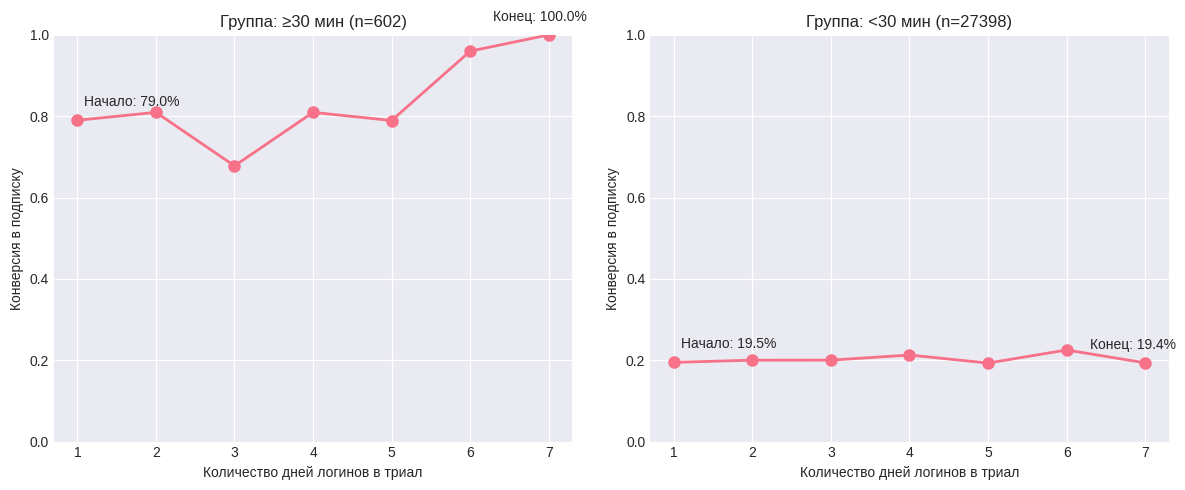

Сводная статистика:

≥30 мин:
  Количество пользователей: 602
  Средняя конверсия: 79.4%
  Среднее дней логинов: 1.9

<30 мин:
  Количество пользователей: 27398
  Средняя конверсия: 19.8%
  Среднее дней логинов: 1.9


In [37]:
# Создаем группы
df['watch_group'] = df['avg_min_watch_daily'] >= 30
group_names = {True: '≥30 мин', False: '<30 мин'}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for idx, (group_val, group_name) in enumerate(group_names.items()):
    group_data = df[df['watch_group'] == group_val]

    # Расчет конверсии
    conversion_by_days = (
        group_data.groupby("number_of_days_logged")
                  .apply(lambda x: 1 - x["churn"].mean())
                  .reset_index(name="conversion_rate")
    )

    # График
    axes[idx].plot(
        conversion_by_days["number_of_days_logged"],
        conversion_by_days["conversion_rate"],
        marker="o", linewidth=2, markersize=8
    )

    axes[idx].set_xlabel("Количество дней логинов в триал")
    axes[idx].set_ylabel("Конверсия в подписку")
    axes[idx].set_title(f"Группа: {group_name} (n={len(group_data)})")
    axes[idx].grid(True)
    axes[idx].set_ylim(0, 1)

    # Добавляем аннотации для ключевых точек
    max_days = conversion_by_days["number_of_days_logged"].max()
    if len(conversion_by_days) > 0:
        initial_rate = conversion_by_days.iloc[0]["conversion_rate"]
        final_rate = conversion_by_days.iloc[-1]["conversion_rate"]

        axes[idx].annotate(f"Начало: {initial_rate:.1%}",
                          xy=(conversion_by_days.iloc[0]["number_of_days_logged"], initial_rate),
                          xytext=(5, 10), textcoords='offset points')

        axes[idx].annotate(f"Конец: {final_rate:.1%}",
                          xy=(max_days, final_rate),
                          xytext=(-40, 10), textcoords='offset points')

plt.tight_layout()
plt.show()

# Статистика по группам
print("Сводная статистика:")
for group_val, group_name in group_names.items():
    group_data = df[df['watch_group'] == group_val]
    avg_conversion = 1 - group_data['churn'].mean()
    print(f"\n{group_name}:")
    print(f"  Количество пользователей: {len(group_data)}")
    print(f"  Средняя конверсия: {avg_conversion:.1%}")
    print(f"  Среднее дней логинов: {group_data['number_of_days_logged'].mean():.1f}")

### Вывод:  3-й день — критический момент. Нужно удержать активность пользователей среди пользователей смотрящих > 30 минут.

In [38]:
import gradio as gr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

def analyze_conversion_by_days(df, threshold_minutes=30, max_days=None):
    """
    Анализирует конверсию в зависимости от дней логинов по группам просмотра
    """
    # Создаем группы по порогу
    df['watch_group'] = df['avg_min_watch_daily'] >= threshold_minutes
    group_names = {True: f'≥{threshold_minutes} мин', False: f'<{threshold_minutes} мин'}

    # Если не задан max_days, берем максимальное значение из данных
    if max_days is None:
        max_days = int(df['number_of_days_logged'].max())

    # Создаем фигуру
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    stats_summary = []

    for idx, (group_val, group_name) in enumerate(group_names.items()):
        group_data = df[df['watch_group'] == group_val].copy()

        if len(group_data) == 0:
            axes[idx].text(0.5, 0.5, f'Нет данных для группы\n{group_name}',
                          ha='center', va='center', transform=axes[idx].transAxes,
                          fontsize=12)
            axes[idx].set_title(f"Группа: {group_name} (n=0)")
            stats_summary.append({
                'group': group_name,
                'n_users': 0,
                'avg_conversion': 0,
                'avg_days': 0,
                'conversion_data': pd.DataFrame()
            })
            continue

        # Сортируем по дням логинов для корректного отображения
        group_data_sorted = group_data.sort_values('number_of_days_logged')

        # Расчет конверсии
        conversion_by_days = (
            group_data_sorted.groupby("number_of_days_logged")
                           .apply(lambda x: 1 - x["churn"].mean())
                           .reset_index(name="conversion_rate")
        )

        # Рассчитываем кумулятивную конверсию
        conversion_by_days['cumulative_users'] = (
            group_data_sorted.groupby("number_of_days_logged").size().values
        )
        conversion_by_days['cumulative_conversion'] = conversion_by_days['conversion_rate'].cumsum() / (idx + 1)

        # Линейная регрессия для тренда
        if len(conversion_by_days) > 1:
            x = conversion_by_days["number_of_days_logged"].values
            y = conversion_by_days["conversion_rate"].values
            slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
            trend_line = intercept + slope * x

        # График конверсии
        axes[idx].plot(
            conversion_by_days["number_of_days_logged"],
            conversion_by_days["conversion_rate"],
            marker="o", linewidth=2, markersize=8, color='#2E86AB',
            label='Конверсия'
        )

        # Линия тренда
        if len(conversion_by_days) > 1:
            axes[idx].plot(
                conversion_by_days["number_of_days_logged"],
                trend_line,
                'r--', linewidth=1.5, alpha=0.7,
                label=f'Тренд (R²={r_value**2:.3f})'
            )

        axes[idx].set_xlabel("Количество дней логинов в триал", fontsize=11)
        axes[idx].set_ylabel("Конверсия в подписку", fontsize=11)
        axes[idx].set_title(f"Группа: {group_name}\n(n={len(group_data):,} пользователей)",
                          fontsize=12, fontweight='bold')
        axes[idx].grid(True, alpha=0.3)
        axes[idx].set_ylim(0, 1.05)
        axes[idx].set_xlim(0, max_days + 1)
        axes[idx].legend(fontsize=10)

        # Добавляем аннотации для ключевых точек
        if len(conversion_by_days) > 0:
            # Начальная точка
            initial_rate = conversion_by_days.iloc[0]["conversion_rate"]
            initial_days = conversion_by_days.iloc[0]["number_of_days_logged"]
            axes[idx].annotate(f"Начало: {initial_rate:.1%}",
                             xy=(initial_days, initial_rate),
                             xytext=(10, 10), textcoords='offset points',
                             fontsize=9, bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.8))

            # Конечная точка
            final_rate = conversion_by_days.iloc[-1]["conversion_rate"]
            final_days = conversion_by_days.iloc[-1]["number_of_days_logged"]
            axes[idx].annotate(f"Конец: {final_rate:.1%}",
                             xy=(final_days, final_rate),
                             xytext=(-40, 10), textcoords='offset points',
                             fontsize=9, bbox=dict(boxstyle='round,pad=0.3', facecolor='lightgreen', alpha=0.8))

            # Ищем критический день (максимальный прирост)
            if len(conversion_by_days) > 1:
                conversion_by_days['change'] = conversion_by_days['conversion_rate'].diff()
                max_change_idx = conversion_by_days['change'].idxmax()
                if max_change_idx > 0:
                    crit_day = conversion_by_days.loc[max_change_idx, "number_of_days_logged"]
                    crit_rate = conversion_by_days.loc[max_change_idx, "conversion_rate"]
                    crit_change = conversion_by_days.loc[max_change_idx, "change"]

                    axes[idx].axvline(x=crit_day, color='red', linestyle='--', alpha=0.5)
                    axes[idx].annotate(f"Критический день {crit_day}\nΔ={crit_change:.1%}",
                                     xy=(crit_day, crit_rate),
                                     xytext=(20, -20), textcoords='offset points',
                                     fontsize=9, color='red', fontweight='bold',
                                     bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.9))

        # Собираем статистику
        avg_conversion = 1 - group_data['churn'].mean()
        avg_days = group_data['number_of_days_logged'].mean()

        stats_summary.append({
            'group': group_name,
            'n_users': len(group_data),
            'avg_conversion': avg_conversion,
            'avg_days': avg_days,
            'conversion_data': conversion_by_days,
            'slope': slope if len(conversion_by_days) > 1 else None,
            'r_squared': r_value**2 if len(conversion_by_days) > 1 else None
        })

    plt.tight_layout()

    # Создаем второй график - сравнение групп
    fig2, ax2 = plt.subplots(figsize=(10, 6))

    colors = ['#FF6B6B', '#4ECDC4']
    bar_positions = np.arange(len(stats_summary))
    bar_width = 0.35

    # Средняя конверсия
    avg_conversions = [s['avg_conversion'] for s in stats_summary]
    bars1 = ax2.bar(bar_positions - bar_width/2, avg_conversions,
                   bar_width, label='Средняя конверсия',
                   color=colors, alpha=0.8, edgecolor='black')

    # Средние дни активности
    avg_days = [s['avg_days'] for s in stats_summary]
    bars2 = ax2.bar(bar_positions + bar_width/2, avg_days,
                   bar_width, label='Средние дни логинов',
                   color=[c.replace('6B', '8B') for c in colors],
                   alpha=0.8, edgecolor='black')

    ax2.set_xlabel('Группы просмотра', fontsize=12)
    ax2.set_title(f'Сравнение групп по порогу {threshold_minutes} минут',
                 fontsize=14, fontweight='bold', y=1.02)
    ax2.set_xticks(bar_positions)
    ax2.set_xticklabels([s['group'] for s in stats_summary], fontsize=11)
    ax2.legend(fontsize=11)
    ax2.grid(axis='y', alpha=0.3)

    # Добавляем значения на столбцы
    for i, (bar1, bar2) in enumerate(zip(bars1, bars2)):
        height1 = bar1.get_height()
        height2 = bar2.get_height()
        ax2.text(bar1.get_x() + bar1.get_width()/2., height1 + 0.01,
                f'{height1:.1%}', ha='center', va='bottom', fontsize=10, fontweight='bold')
        ax2.text(bar2.get_x() + bar2.get_width()/2., height2 + 0.01,
                f'{height2:.1f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

    plt.tight_layout()

    # Формируем текстовый вывод
    analysis_text = f"""
    ## Анализ конверсии по дням активности
    ### Порог времени просмотра: {threshold_minutes} минут

    ### Сводная статистика:
    """

    for stats_item in stats_summary:
        if stats_item['n_users'] > 0:
            analysis_text += f"""
    **{stats_item['group']}:**
    - Пользователей: {stats_item['n_users']:,}
    - Средняя конверсия: {stats_item['avg_conversion']:.1%}
    - Среднее дней активности: {stats_item['avg_days']:.1f}
    """
            if stats_item['slope'] is not None:
                trend_direction = "растёт" if stats_item['slope'] > 0 else "падает"
                analysis_text += f"- Тренд конверсии: {trend_direction} (наклон: {stats_item['slope']:.4f}, R²={stats_item['r_squared']:.3f})\n"

    return fig, fig2, analysis_text

def create_conversion_interface(df, initial_threshold=30):
    """
    Создает Gradio интерфейс для анализа конверсии
    """
    # Определяем диапазон для слайдера
    min_threshold = int(max(1, df['avg_min_watch_daily'].min()))
    max_threshold = int(df['avg_min_watch_daily'].max())
    median_threshold = int(df['avg_min_watch_daily'].median())

    # Определяем шаг
    threshold_range = max_threshold - min_threshold
    if threshold_range > 100:
        step = 10
    elif threshold_range > 50:
        step = 5
    else:
        step = 1

    with gr.Blocks(title="Анализ конверсии по дням активности", theme=gr.themes.Soft()) as demo:
        gr.Markdown("# Анализ конверсии по дням активности в триале")
        gr.Markdown("Исследуйте, как конверсия в подписку зависит от количества дней активности в триальном периоде для разных групп пользователей.")

        with gr.Row():
            with gr.Column(scale=1):
                gr.Markdown("### Настройки анализа")

                threshold_slider = gr.Slider(
                    minimum=min_threshold,
                    maximum=max_threshold,
                    value=initial_threshold,
                    step=step,
                    label="Порог времени просмотра (минут)",
                    info=f"Диапазон: {min_threshold}-{max_threshold} мин"
                )

                max_days_input = gr.Slider(
                    minimum=1,
                    maximum=int(df['number_of_days_logged'].max()),
                    value=min(7, int(df['number_of_days_logged'].max())),
                    step=1,
                    label="Максимальное количество дней для анализа",
                    info="Ограничьте диапазон дней для фокуса на ранней активности"
                )

                gr.Markdown("### Быстрые пороги")
                quick_buttons = gr.Row()
                with quick_buttons:
                    for value in [5, 10, 15, 30, 60]:
                        if min_threshold <= value <= max_threshold:
                            gr.Button(f"{value} мин", size="sm").click(
                                fn=lambda x=value: x,
                                outputs=threshold_slider
                            )
                info_box = gr.Markdown("Настройте параметры и нажмите 'Обновить'")

            with gr.Column(scale=2):
                gr.Markdown("### Визуализация результатов")

                with gr.Tab("Конверсия по дням"):
                    plot1 = gr.Plot(label="Динамика конверсии по дням")

                with gr.Tab("Сравнение групп"):
                    plot2 = gr.Plot(label="Сравнительная статистика групп")

                with gr.Tab("Анализ"):
                    analysis_output = gr.Markdown(label="Детальный анализ")

        # Кнопка обновления
        update_btn = gr.Button("Обновить анализ", variant="primary")

        def update_analysis(threshold, max_days):
            fig1, fig2, analysis = analyze_conversion_by_days(df, threshold, max_days)
            return fig1, fig2, analysis

        # Подключаем обработчики
        update_btn.click(
            fn=update_analysis,
            inputs=[threshold_slider, max_days_input],
            outputs=[plot1, plot2, analysis_output]
        )

        threshold_slider.change(
            fn=update_analysis,
            inputs=[threshold_slider, max_days_input],
            outputs=[plot1, plot2, analysis_output]
        )

        max_days_input.change(
            fn=update_analysis,
            inputs=[threshold_slider, max_days_input],
            outputs=[plot1, plot2, analysis_output]
        )

        # Инициализация
        demo.load(
            fn=lambda: update_analysis(initial_threshold, min(7, int(df['number_of_days_logged'].max()))),
            outputs=[plot1, plot2, analysis_output]
        )

        gr.Markdown("---")
        gr.Markdown("""
        ### Как интерпретировать результаты:

        1. **Критический день** - день с максимальным приростом конверсии (помечен красной линией)
        2. **Линия тренда** - показывает общее направление изменения конверсии
        3. **Разница между группами** - показывает влияние времени просмотра на конверсию
        """)

    return demo

def run_conversion_analysis(df, initial_threshold=30):
    """
    Запускает интерфейс анализа конверсии
    """
    demo = create_conversion_interface(df, initial_threshold)
    demo.launch(share=False, debug=False)

run_conversion_analysis(df, initial_threshold=30)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
Note: opening Chrome Inspector may crash demo inside Colab notebooks.
* To create a public link, set `share=True` in `launch()`.


<IPython.core.display.Javascript object>

# Связь категориальных признаков и целевой переменной внутри группы с просмотрами более 30 минут и 3 днями логирований

## Гипотеза 2.3. Среди пользователей, активных в течении 3х дней и смотрящих более 30 минут в день, существуют статистически значимые различия в оттоке в зависимости от категориальных признаков (город, устройство, источник трафика, любимый жанр).

### Стратегия проверки

Выделение целевой группы: фильтрация пользователей с avg_min_watch_daily > 30 и number_of_days_logged = 3
Для каждого one-hot столбца (город, устройство, источник, жанр):
 - Построение таблицы сопряженности 2×2 с переменной churn
 - Расчет коэффициента фи (φ) для измерения силы и направления связи
 - Расчет p-value через тест хи-квадрат
Сортировка признаков по абсолютному значению |φ|

### Статистический метод

Тест хи-квадрат Пирсона для независимости с расчетом коэффициента фи (φ).

#### Обоснование выбора теста:

Структура данных оптимальна для метода:
- Целевая переменная churn — бинарная (0/1)
- Признаки после one-hot кодирования — бинарные (0/1)

# Проверка гипотезы статистическими тестами

### H₀: Среди пользователей, активных в течении 3х дней и смотрящих более 30 минут в день, категориальный признак X и отток пользователей (churn) статистически независимы. P(churn=1 | X=1, avg_min_watch_daily > 30, number_of_days_logged = 3) = P(churn=1 | X=0, avg_min_watch_daily > 30, number_of_days_logged = 3)
### H₁: Среди пользователей, активных в течении 3х дней и смотрящих более 30 минут в день, существует статистически значимая зависимость между категориальным признаком X и оттоком пользователей. P(churn=1 | X=1, avg_min_watch_daily > 30, number_of_days_logged = 3) ≠ P(churn=1 | X=0, avg_min_watch_daily > 30, number_of_days_logged = 3)

In [39]:
# Фильтруем пользователей с >30 минут просмотра и 3 днями логинов
filtered_group = data_encoded[
    (data_encoded['avg_min_watch_daily'] > 30) &
    (data_encoded['number_of_days_logged'] == 3)
]

# Проверяем размер группы
print(f"Пользователей с просмотром >30 мин и 3 днями логинов: {len(filtered_group)}")
print(f"Отток в этой группе: {filtered_group['churn'].mean():.1%}")

results = []

for col in filtered_group.columns:
    if any(cat in col for cat in ['city_', 'device_', 'source_', 'favourite_genre_']):
        conf_matrix = pd.crosstab(filtered_group[col], filtered_group['churn'])

        # Фи-коэффициент
        a, b, c, d = conf_matrix.values.flatten()
        phi = (a*d - b*c) / np.sqrt((a+b)*(c+d)*(a+c)*(b+d))

        # p-value
        _, p_value, _, _ = chi2_contingency(conf_matrix)

        results.append({
            'feature': col,
            'phi_coefficient': round(phi, 4),
            'p_value': round(p_value, 6),
            'significant': p_value < 0.05
        })

# Создаем и сортируем DataFrame
filtered_results = pd.DataFrame(results)
filtered_results = filtered_results.sort_values('phi_coefficient', key=abs, ascending=False)

print("\nКатегориальные признаки для группы (>30 мин, 3 дня логинов):")
print(filtered_results[['feature', 'phi_coefficient', 'p_value', 'significant']])

Пользователей с просмотром >30 мин и 3 днями логинов: 59
Отток в этой группе: 32.2%

Категориальные признаки для группы (>30 мин, 3 дня логинов):
                     feature  phi_coefficient   p_value  significant
3                 city_Other           0.4415  0.003839         True
15        source_performance           0.2974  0.045270         True
9         city_Yekaterinburg           0.2718  0.187562        False
14            source_organic          -0.2572  0.096430        False
21     favourite_genre_drama           0.2568  0.117439        False
10            device_android          -0.2529  0.130660        False
19    favourite_genre_comedy          -0.2147  0.201398        False
1                city_Moscow          -0.1982  0.224452        False
4                city_Samara           0.1810  0.373349        False
12            device_smarttv           0.1707  0.498320        False
0             city_Krasnodar          -0.1670  0.381075        False
20  favourite_genre_crimin

### Выводы: Среди пользователей, долго смотрящих (>30 мин) и имеющий 3 дня логирований: из малых городов имеют повышенный отток. Также performance-пользователи имеют повышенный отток среди этой категории. (32.2% vs 20.6%).

### Рекомендации: Для пользователей из малых городов (city_Other) продумать персональные промо-акции на 3-й день. Сделать опрос о причинах недовольства. Для performance-трафика проверить соответствие рекламы и реального контента. Для всех в этой группе: отправить Push-уведомление на 3-й день с подборкой контента и напомнить о преимуществах подписки.

# Проанализируем как конверсия меняется в зависимости от количества дней логинов в триал

In [40]:
conversion_by_days = (
    df.groupby("number_of_days_logged")
      .apply(lambda x: 1 - x["churn"].mean())
      .reset_index(name="conversion_rate")
)

conversion_by_days

,number_of_days_logged,conversion_rate
0,1,0.207200
1,2,0.214069
2,3,0.211823
3,4,0.224903
4,5,0.204365
5,6,0.242481
6,7,0.212185


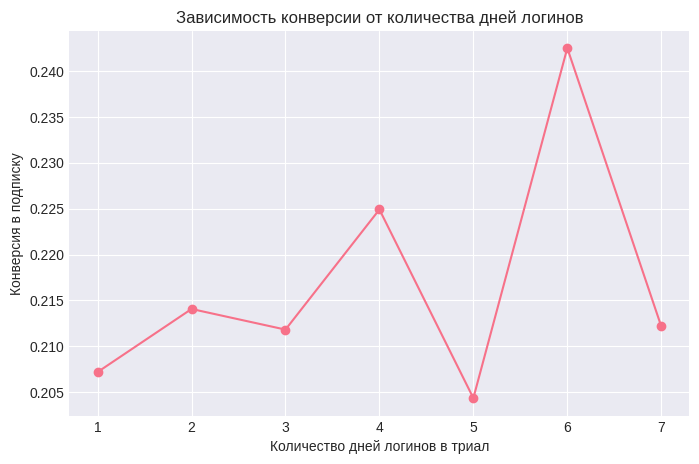

In [41]:
plt.figure(figsize=(8,5))
plt.plot(
    conversion_by_days["number_of_days_logged"],
    conversion_by_days["conversion_rate"],
    marker="o"
)

plt.xlabel("Количество дней логинов в триал")
plt.ylabel("Конверсия в подписку")
plt.title("Зависимость конверсии от количества дней логинов")
plt.grid(True)
plt.show()


Наблюдается **спад конверсии на 5 и 7 дни**. Люди теряют интерес или пользуются только пробным периодом, а затем уходят

## Гипотеза 3: Конверсия падает на 5-й день триала

**H0:** Снижение конверсии на 5-й день триала является случайным и не связано с особенностями поведения пользователей в середине триального периода.

**H1:** Снижение конверсии на 5-й день триала обусловлено тем, что пользователи, которые не нашли достаточно ценного контента к середине триала (имели низкую активность просмотра), отписываются за пару дней до окончания триала.

### Стратегия проверки

Разделим пользователей на 2 группы:
1. те, которые были активны на 5-й день и совершили подписку
2. те, которые были активны на 5-й день и не совершили подписку.

Чтобы проверить, предсказывает ли активность перед спадом сам спад конверсии, проанализируем среднее время просмотра на 4-й день триала (день перед спадом).

### Статистический метод

Тест Манна-Уитни

Используется, поскольку является непараметрическим и не требует нормальности, а также устойчив к выбросам

In [42]:
import scipy.stats as stats

# Рассчитаем конверсию по дням активности
conversion_by_days = (
    df.groupby("number_of_days_logged")
      .agg(
          total_users=('user_id', 'count'),
          conversions=('churn', lambda x: (x == 0).sum()),
          conversion_rate=('churn', lambda x: (1 - x.mean()) * 100),
          avg_watch_time=('avg_min_watch_daily', 'mean')
      )
      .reset_index()
)

print("Конверсия и среднее время просмотра по дням активности:")
print(conversion_by_days.to_string())


# Сравним пользователей с 4 и 5 днями активности
users_4_days = df[df['number_of_days_logged'] == 4].copy()
users_5_days = df[df['number_of_days_logged'] == 5].copy()

print(f"\nПользователей с 4 днями активности: {len(users_4_days)}")
print(f"Пользователей с 5 днями активности: {len(users_5_days)}")

# Сравнение среднего времени просмотра между группами 4 и 5 дней
print(f"\nСравнение среднего времени просмотра:")
print(f"4 дня: {users_4_days['avg_min_watch_daily'].mean():.1f} мин/день")
print(f"5 дней: {users_5_days['avg_min_watch_daily'].mean():.1f} мин/день")

# Тест Манна-Уитни для сравнения распределений
stat_4_5, p_4_5 = stats.mannwhitneyu(
    users_4_days['avg_min_watch_daily'].dropna(),
    users_5_days['avg_min_watch_daily'].dropna(),
    alternative='two-sided'
)

print(f"\nТест Манна-Уитни (4 дня vs 5 дней):")
print(f"p-value = {p_4_5:.5f}")
if p_4_5 < 0.05:
    print("Есть статистически значимая разница в среднем времени просмотра")
else:
    print("Нет статистически значимой разницы в среднем времени просмотра")

# Основной тест: сравнение вовлеченности внутри группы 5 дней
# Разделим пользователей с 5 днями активности на конвертированных и неконвертированных
users_5_converted = users_5_days[users_5_days['churn'] == 0]
users_5_not_converted = users_5_days[users_5_days['churn'] == 1]

print(f"\nАнализ внутри группы с 5 днями активности:")
print(f"Конвертировалось: {len(users_5_converted)} ({len(users_5_converted)/len(users_5_days)*100:.1f}%)")
print(f"Не конвертировалось: {len(users_5_not_converted)} ({len(users_5_not_converted)/len(users_5_days)*100:.1f}%)")
print(f"\nСреднее время просмотра:")
print(f"Конвертированные: {users_5_converted['avg_min_watch_daily'].mean():.1f} мин/день")
print(f"Неконвертированные: {users_5_not_converted['avg_min_watch_daily'].mean():.1f} мин/день")

# Тест Манна-Уитни для сравнения внутри группы 5 дней
stat_5_groups, p_5_groups = stats.mannwhitneyu(
    users_5_converted['avg_min_watch_daily'].dropna(),
    users_5_not_converted['avg_min_watch_daily'].dropna(),
    alternative='greater'
)

print(f"\nТест Манна-Уитни (внутри 5 дней, конвертированные vs неконвертированные):")
print(f"p-value = {p_5_groups:.5f}")
print(f"U-статистика = {stat_5_groups:.0f}")

if p_5_groups < 0.05:
    print("У конвертированных пользователей с 5 днями активности")
    print("среднее время просмотра статистически значимо выше")
else:
    print("Нет статистически значимой разницы во времени просмотра")
    print("между конвертированными и неконвертированными пользователями с 5 днями активности")

# Дополнительный анализ: сравним с пользователями, у которых 4 дня  и 6 дней активности
users_4_converted = users_4_days[users_4_days['churn'] == 0]
users_4_not_converted = users_4_days[users_4_days['churn'] == 1]

users_6_days = df[df['number_of_days_logged'] == 6].copy()
users_6_converted = users_6_days[users_6_days['churn'] == 0]
users_6_not_converted = users_6_days[users_6_days['churn'] == 1]


print(f"\nСравнение с пользователями 4 дней активности:")
print(f"Конвертированные (4 дня): {users_4_converted['avg_min_watch_daily'].mean():.1f} мин/день")
print(f"Конвертированные (5 дней): {users_5_converted['avg_min_watch_daily'].mean():.1f} мин/день")
print(f"Конвертированные (6 дней): {users_6_converted['avg_min_watch_daily'].mean():.1f} мин/день")

print(f"\nНеконвертированные (4 дня): {users_4_not_converted['avg_min_watch_daily'].mean():.1f} мин/день")
print(f"Неконвертированные (5 дня): {users_5_not_converted['avg_min_watch_daily'].mean():.1f} мин/день")
print(f"Неконвертированные (6 дня): {users_6_not_converted['avg_min_watch_daily'].mean():.1f} мин/день")

Конверсия и среднее время просмотра по дням активности:
   number_of_days_logged  total_users  conversions  conversion_rate  avg_watch_time
0                      1        17360         3597        20.720046        7.780791
1                      2         4620          989        21.406926        7.854345
2                      3         2436          516        21.182266        7.927081
3                      4         1036          233        22.490347        7.841756
4                      5         1008          206        20.436508        7.519630
5                      6         1064          258        24.248120        8.068037
6                      7          476          101        21.218487        7.971326

Пользователей с 4 днями активности: 1036
Пользователей с 5 днями активности: 1008

Сравнение среднего времени просмотра:
4 дня: 7.8 мин/день
5 дней: 7.5 мин/день

Тест Манна-Уитни (4 дня vs 5 дней):
p-value = 0.48560
Нет статистически значимой разницы в среднем времени п


Анализ оптимального порога вовлеченности


Конверсия при разных порогах вовлеченности (для 5 дней активности):
   threshold  users_above  users_below  conv_above  conv_below       diff
0         10          248          760   48.790323   11.184211  37.606112
1         15          141          867   58.156028   14.302191  43.853837
2         20           62          946   72.580645   17.019027  55.561618
3         25           37          971   72.972973   18.434604  54.538369
4         30           19          989   78.947368   19.312437  59.634932

Оптимальный порог вовлеченности: 30.0 мин/день
   Конверсия выше порога: 78.9%
   Конверсия ниже порога: 19.3%
   Разница: +59.6%


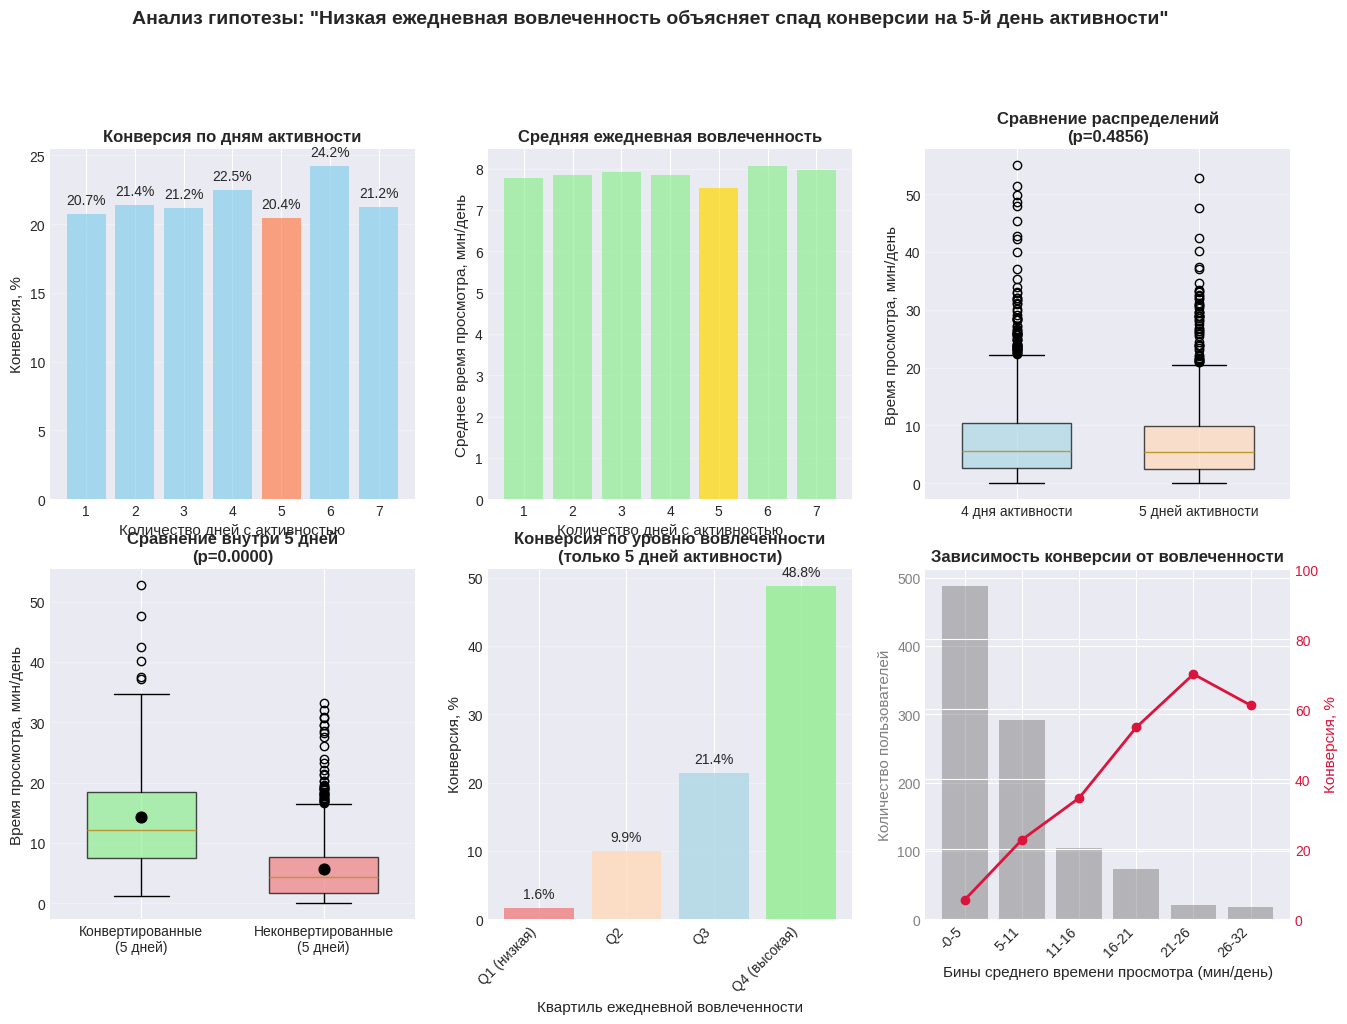

In [43]:
# Создадим визуализацию
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Анализ гипотезы: "Низкая ежедневная вовлеченность объясняет спад конверсии на 5-й день активности"',
             fontsize=14, fontweight='bold', y=1.02)

# График 1: Конверсия по дням активности
ax1 = axes[0, 0]
bars = ax1.bar(conversion_by_days['number_of_days_logged'],
               conversion_by_days['conversion_rate'],
               color=['skyblue' if x != 5 else 'coral' for x in conversion_by_days['number_of_days_logged']],
               alpha=0.7)
ax1.set_xlabel("Количество дней с активностью", fontsize=11)
ax1.set_ylabel("Конверсия, %", fontsize=11)
ax1.set_title("Конверсия по дням активности", fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='y')

for bar, conv in zip(bars, conversion_by_days['conversion_rate']):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.5,
             f'{conv:.1f}%', ha='center', va='bottom', fontsize=10)

# График 2: Среднее время просмотра по дням активности
ax2 = axes[0, 1]
ax2.bar(conversion_by_days['number_of_days_logged'],
        conversion_by_days['avg_watch_time'],
        color=['lightgreen' if x != 5 else 'gold' for x in conversion_by_days['number_of_days_logged']],
        alpha=0.7)
ax2.set_xlabel("Количество дней с активностью", fontsize=11)
ax2.set_ylabel("Среднее время просмотра, мин/день", fontsize=11)
ax2.set_title("Средняя ежедневная вовлеченность", fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

# График 3: Сравнение распределений времени просмотра (4 vs 5 дней)
ax3 = axes[0, 2]

box_data = [users_4_days['avg_min_watch_daily'].dropna(),
            users_5_days['avg_min_watch_daily'].dropna()]
labels = ['4 дня активности', '5 дней активности']
boxplot = ax3.boxplot(box_data, labels=labels, patch_artist=True, widths=0.6)

colors_box = ['lightblue', 'peachpuff']
for patch, color in zip(boxplot['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax3.set_ylabel("Время просмотра, мин/день", fontsize=11)
ax3.set_title(f"Сравнение распределений\n(p={p_4_5:.4f})", fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3, axis='y')

# График 4: Сравнение внутри группы 5 дней
ax4 = axes[1, 0]

box_data_5 = [users_5_converted['avg_min_watch_daily'].dropna(),
              users_5_not_converted['avg_min_watch_daily'].dropna()]
labels_5 = ['Конвертированные\n(5 дней)', 'Неконвертированные\n(5 дней)']
boxplot_5 = ax4.boxplot(box_data_5, labels=labels_5, patch_artist=True, widths=0.6)

colors_5 = ['lightgreen', 'lightcoral']
for patch, color in zip(boxplot_5['boxes'], colors_5):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

for i, data in enumerate(box_data_5, 1):
    mean_val = np.mean(data)
    ax4.scatter(i, mean_val, color='black', zorder=3, s=60)

ax4.set_ylabel("Время просмотра, мин/день", fontsize=11)
ax4.set_title(f"Сравнение внутри 5 дней\n(p={p_5_groups:.4f})", fontsize=12, fontweight='bold')
ax4.grid(True, alpha=0.3, axis='y')

# График 5: Зависимость конверсии от времени просмотра для 5 дней
ax5 = axes[1, 1]

users_5_days['watch_bin'] = pd.qcut(users_5_days['avg_min_watch_daily'],
                                     q=4,
                                     labels=['Q1 (низкая)', 'Q2', 'Q3', 'Q4 (высокая)'])
bin_conversion = users_5_days.groupby('watch_bin')['churn'].mean().apply(lambda x: (1-x)*100)

colors_bin = ['lightcoral', 'peachpuff', 'lightblue', 'lightgreen']
bars_bin = ax5.bar(range(len(bin_conversion)), bin_conversion, color=colors_bin, alpha=0.8)

ax5.set_xlabel("Квартиль ежедневной вовлеченности", fontsize=11)
ax5.set_ylabel("Конверсия, %", fontsize=11)
ax5.set_title("Конверсия по уровню вовлеченности\n(только 5 дней активности)",
              fontsize=12, fontweight='bold')
ax5.set_xticks(range(len(bin_conversion)))
ax5.set_xticklabels(bin_conversion.index, rotation=45, ha='right')
ax5.grid(True, alpha=0.3, axis='y')

for bar, conv in zip(bars_bin, bin_conversion):
    height = bar.get_height()
    ax5.text(bar.get_x() + bar.get_width()/2., height + 1,
             f'{conv:.1f}%', ha='center', va='bottom', fontsize=10)

# График 6: Совместная визуализация конверсии и вовлеченности

ax6 = axes[1, 2]

engagement_bins_series = pd.cut(users_5_days['avg_min_watch_daily'], bins=10)

grouped = users_5_days.groupby(engagement_bins_series).agg(
    conversion_rate=('churn', lambda x: (1 - x.mean()) * 100),
    avg_engagement=('avg_min_watch_daily', 'mean'),
    count=('user_id', 'count')
).reset_index()

grouped = grouped.rename(columns={'avg_min_watch_daily': 'engagement_bins'})

grouped = grouped[grouped['count'] > 10]

ax6_bar = ax6.bar(range(len(grouped)), grouped['count'],
                  alpha=0.5, color='gray', label='Количество пользователей')
ax6.set_xlabel("Бины среднего времени просмотра (мин/день)", fontsize=11)
ax6.set_ylabel("Количество пользователей", fontsize=11, color='gray')
ax6.tick_params(axis='y', labelcolor='gray')

ax6_line = ax6.twinx()
ax6_line.plot(range(len(grouped)), grouped['conversion_rate'],
              color='crimson', marker='o', linewidth=2, markersize=6,
              label='Конверсия, %')
ax6_line.set_ylabel("Конверсия, %", fontsize=11, color='crimson')
ax6_line.tick_params(axis='y', labelcolor='crimson')
ax6_line.set_ylim(0, 100)

ax6.set_xticks(range(len(grouped)))
ax6.set_xticklabels([f"{interval.left:.0f}-{interval.right:.0f}"
                     for interval in grouped['engagement_bins']],
                    rotation=45, ha='right')

ax6.set_title("Зависимость конверсии от вовлеченности", fontsize=12, fontweight='bold')


# Поиск оптимального порога вовлеченности
print("\nАнализ оптимального порога вовлеченности\n")

# Создаем различные пороги и смотрим конверсию
thresholds = [10, 15, 20, 25, 30, 40, 50]
results = []

for threshold in thresholds:
    above_threshold = users_5_days[users_5_days['avg_min_watch_daily'] >= threshold]
    below_threshold = users_5_days[users_5_days['avg_min_watch_daily'] < threshold]

    if len(above_threshold) > 10 and len(below_threshold) > 10:
        conv_above = (1 - above_threshold['churn'].mean()) * 100
        conv_below = (1 - below_threshold['churn'].mean()) * 100

        results.append({
            'threshold': threshold,
            'users_above': len(above_threshold),
            'users_below': len(below_threshold),
            'conv_above': conv_above,
            'conv_below': conv_below,
            'diff': conv_above - conv_below
        })

results_df = pd.DataFrame(results)
print("\nКонверсия при разных порогах вовлеченности (для 5 дней активности):")
print(results_df.to_string())

# Находим оптимальный порог
if not results_df.empty:
    optimal = results_df.loc[results_df['diff'].idxmax()]
    print(f"\nОптимальный порог вовлеченности: {optimal['threshold']} мин/день")
    print(f"   Конверсия выше порога: {optimal['conv_above']:.1f}%")
    print(f"   Конверсия ниже порога: {optimal['conv_below']:.1f}%")
    print(f"   Разница: +{optimal['diff']:.1f}%")


Проведем дополнительный анализ: почему именно 5 дней?

In [44]:
# 1. Анализ распределения
print("\n1. Расределение пользователей с 5 днями активности на оставшихся и ушедших:")
print(f"Всего пользователей с 5 днями активности: {len(users_5_days)}")
print(f"Из них подписались: {len(users_5_converted)} ({len(users_5_converted)/len(users_5_days)*100:.1f}%)")
print(f"Из них не подписались: {len(users_5_not_converted)} ({len(users_5_not_converted)/len(users_5_days)*100:.1f}%)")

# 2. Анализ порога вовлеченности
print("\n2. Критический порог вовлеченности:")

# Рассчитаем медиану среднего минимального просмотра для не подписавшихся
median_not_converted = users_5_not_converted['avg_min_watch_daily'].median()
print(f"Медианная вовлеченность неконвертированных: {median_not_converted:.1f} мин/день")

# Сколько не подписавшихся с медианой выше медианы под?
converted_median = users_5_converted['avg_min_watch_daily'].median()
not_converted_above_threshold = users_5_not_converted[users_5_not_converted['avg_min_watch_daily'] >= converted_median]
print(f"Неконвертированных с вовлеченностью ≥{converted_median:.0f} мин: {len(not_converted_above_threshold)}")
print(f"Из них могли бы конвертироваться: ~{len(not_converted_above_threshold)/len(users_5_not_converted)*100:.1f}%")

# 3. Сравнение с другими днями активности
print("\n3. СРАВНЕНИЕ ПО ДНЯМ АКТИВНОСТИ:")
for days in [3, 4, 5, 6, 7]:
    users_days = df[df['number_of_days_logged'] == days]
    if len(users_days) > 0:
        conv_rate = (1 - users_days['churn'].mean()) * 100
        avg_watch = users_days['avg_min_watch_daily'].mean()
        conv_watch = users_days[users_days['churn'] == 0]['avg_min_watch_daily'].mean()
        not_conv_watch = users_days[users_days['churn'] == 1]['avg_min_watch_daily'].mean()

        print(f"{days} дней: Конверсия={conv_rate:.1f}%, "
              f"Среднее={avg_watch:.1f} мин, "
              f"Конверт={conv_watch:.1f} мин, "
              f"Не конверт={not_conv_watch:.1f} мин")

# Создаем финальную визуализацию
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Ключевой инсайт: Качество вовлеченности важнее количества дней активности',
             fontsize=16, fontweight='bold', y=1.05)

# График 1: Две разные группы внутри 5 дней
ax1 = axes[0]
# Гистограмма распределения
ax1.hist(users_5_converted['avg_min_watch_daily'], bins=30, alpha=0.7,
         color='green', label='Конвертированные', density=True)
ax1.hist(users_5_not_converted['avg_min_watch_daily'], bins=30, alpha=0.7,
         color='red', label='Неконвертированные', density=True)
ax1.axvline(x=10, color='black', linestyle='--', linewidth=1.5,
           label='Примерный порог (10 мин)')
ax1.set_xlabel('Среднее время просмотра, мин/день', fontsize=12)
ax1.set_ylabel('Плотность распределения', fontsize=12)
ax1.set_title('Два разных типа пользователей с 5 днями активности', fontsize=14)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Добавляем аннотации
ax1.annotate(f'Конвертированные\n14.3 мин/день',
             xy=(14.3, 0.03), xytext=(20, 0.04),
             arrowprops=dict(arrowstyle='->', color='green'),
             fontsize=10, color='green')
ax1.annotate(f'Неконвертированные\n5.8 мин/день',
             xy=(5.8, 0.05), xytext=(2, 0.06),
             arrowprops=dict(arrowstyle='->', color='red'),
             fontsize=10, color='red')

# График 2: Сравнение конверсии по уровню вовлеченности
ax2 = axes[1]

users_5_days['engagement_group'] = pd.cut(users_5_days['avg_min_watch_daily'],
                                          bins=[0, 5, 10, 15, 20, 30, 100],
                                          labels=['0-5', '5-10', '10-15', '15-20', '20-30', '30+'])
group_stats = users_5_days.groupby('engagement_group').agg(
    conversion_rate=('churn', lambda x: (1 - x.mean()) * 100),
    user_count=('user_id', 'count')
).reset_index()

group_stats = group_stats[group_stats['user_count'] > 10]

bars = ax2.bar(range(len(group_stats)), group_stats['conversion_rate'],
               color=['red', 'orange', 'yellow', 'lightgreen', 'green', 'darkgreen'])
ax2.set_xlabel('Уровень вовлеченности (мин/день)', fontsize=12)
ax2.set_ylabel('Конверсия, %', fontsize=12)
ax2.set_title('Конверсия резко растет после 10 минут в день', fontsize=14)
ax2.set_xticks(range(len(group_stats)))
ax2.set_xticklabels(group_stats['engagement_group'], rotation=45)
ax2.grid(True, alpha=0.3, axis='y')

for i, (bar, conv, count) in enumerate(zip(bars, group_stats['conversion_rate'], group_stats['user_count'])):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 2,
             f'{conv:.0f}%\nn={count}', ha='center', va='bottom', fontsize=9)

# График 3: Сравнение всех групп
ax3 = axes[2]

data_to_plot = []
labels = []

for days in [4, 5]:
    for churn_status in [0, 1]:
        subset = df[(df['number_of_days_logged'] == days) & (df['churn'] == churn_status)]
        if len(subset) > 10:
            data_to_plot.append(subset['avg_min_watch_daily'].dropna())
            status_name = 'Конверт' if churn_status == 0 else 'Не конверт'
            labels.append(f'{days} дней\n{status_name}')

positions = range(1, len(data_to_plot) + 1)
boxplot = ax3.boxplot(data_to_plot, positions=positions, widths=0.6, patch_artist=True)

colors = ['lightgreen', 'lightcoral', 'lightblue', 'pink']
for patch, color in zip(boxplot['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax3.set_xlabel('Группа пользователей', fontsize=12)
ax3.set_ylabel('Среднее время просмотра, мин/день', fontsize=12)
ax3.set_title('Сравнение вовлеченности по группам', fontsize=14)
ax3.set_xticks(positions)
ax3.set_xticklabels(labels, rotation=0)
ax3.grid(True, alpha=0.3, axis='y')

ax3.axhline(y=10, color='gray', linestyle='--', alpha=0.5, linewidth=1)
ax3.text(4.5, 10.5, 'Порог 10 мин/день', fontsize=9, color='gray')

plt.tight_layout()
plt.show()


1. Расределение пользователей с 5 днями активности на оставшихся и ушедших:
Всего пользователей с 5 днями активности: 1008
Из них подписались: 206 (20.4%)
Из них не подписались: 802 (79.6%)

2. Критический порог вовлеченности:
Медианная вовлеченность неконвертированных: 4.4 мин/день
Неконвертированных с вовлеченностью ≥12 мин: 96
Из них могли бы конвертироваться: ~12.0%

3. СРАВНЕНИЕ ПО ДНЯМ АКТИВНОСТИ:
3 дней: Конверсия=21.2%, Среднее=7.9 мин, Конверт=14.9 мин, Не конверт=6.0 мин
4 дней: Конверсия=22.5%, Среднее=7.8 мин, Конверт=14.9 мин, Не конверт=5.8 мин
5 дней: Конверсия=20.4%, Среднее=7.5 мин, Конверт=14.3 мин, Не конверт=5.8 мин
6 дней: Конверсия=24.2%, Среднее=8.1 мин, Конверт=15.0 мин, Не конверт=5.8 мин
7 дней: Конверсия=21.2%, Среднее=8.0 мин, Конверт=15.3 мин, Не конверт=6.0 мин


# **Вывод**

Гипотеза H1 потверждена

Тест Манна-Уитни (внутри 5 дней, конвертированные vs неконвертированные):

p-value = 0.00000

U-статистика = 136143

У конвертированных пользователей с 5 днями активности
среднее время просмотра статистически значимо выше


Фактически обнаружено:
1. Количество дней активности само по себе не определяет конверсию
2. Ключевой фактор - КАЧЕСТВО использования (среднее время просмотра в день)
3. Пользователи с 5 днями активности делятся на две группы:

   • Глубоко вовлеченные (14+ мин/день) → конвертируются хорошо

   • Поверхностно вовлеченные (~6 мин/день) → конвертируются плохо

Рекомендуемые действия:
1. Сфокусироваться на увеличении глубины вовлеченности, а не частоты посещений
2. Внедрить систему early warning для пользователей с низкой ежедневной вовлеченностью
3. Оптимизировать подрорку контента пользователей в первые 3-4 дня триала

In [49]:
import gradio as gr
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats
from io import StringIO


def create_engagement_analysis(threshold_minutes, min_days_active, comparison_days):
    """
    Анализ порога вовлеченности с интерактивными параметрами
    """
    # Проверяем, что comparison_days не пустой
    if not comparison_days:
        comparison_days = [min_days_active]

    # Фильтруем пользователей с минимальным количеством дней
    filtered_df = df[df['number_of_days_logged'] >= min_days_active].copy()

    # Создаем группы по порогу
    filtered_df['above_threshold'] = filtered_df['avg_min_watch_daily'] >= threshold_minutes
    filtered_df['converted'] = filtered_df['churn'] == 0

    # Анализ конверсии
    group_analysis = filtered_df.groupby(['number_of_days_logged', 'above_threshold']).agg({
        'user_id': 'count',
        'churn': lambda x: (1 - x.mean()) * 100
    }).reset_index()

    # Переименовываем колонки
    group_analysis.columns = ['days_active', 'above_threshold', 'user_count', 'conversion_rate']

    # Создаем фигуры
    fig1, ax1 = plt.subplots(figsize=(12, 6))

    # 1. Конверсия по группам
    colors = plt.cm.tab10(np.linspace(0, 1, len(comparison_days)))

    # Подготовка данных для графика
    bar_width = 0.8 / len(comparison_days)

    for idx, days in enumerate(sorted(comparison_days)):
        subset = group_analysis[group_analysis['days_active'] == days]
        if len(subset) == 2:  # есть обе группы
            # Данные для ниже/выше порога
            below_data = subset[subset['above_threshold'] == False]
            above_data = subset[subset['above_threshold'] == True]

            below_rate = below_data['conversion_rate'].iloc[0] if len(below_data) > 0 else 0
            above_rate = above_data['conversion_rate'].iloc[0] if len(above_data) > 0 else 0

            # Позиции для столбцов
            below_pos = idx * bar_width
            above_pos = 1 + idx * bar_width

            # Рисуем столбцы
            ax1.bar(below_pos, below_rate, width=bar_width*0.8,
                   color='red', alpha=0.7, label=f'{days} дн.' if idx == 0 else "")
            ax1.bar(above_pos, above_rate, width=bar_width*0.8,
                   color='green', alpha=0.7)

            # Добавляем подписи
            ax1.text(below_pos, below_rate + 1, f'{below_rate:.1f}%',
                    ha='center', fontsize=9)
            ax1.text(above_pos, above_rate + 1, f'{above_rate:.1f}%',
                    ha='center', fontsize=9)

    ax1.set_xlabel('Группа')
    ax1.set_ylabel('Конверсия, %')
    ax1.set_title(f'Конверсия по порогу вовлеченности ({threshold_minutes} мин/день)')
    ax1.set_xticks([0.5, 1.5])
    ax1.set_xticklabels(['Ниже порога', 'Выше порога'])
    ax1.legend(title='Дней активности')
    ax1.grid(True, alpha=0.3)
    ax1.set_ylim(0, max(group_analysis['conversion_rate'].max() * 1.2, 100))

    plt.tight_layout()
    fig1.canvas.draw()

    # 2. Распределение времени просмотра
    fig2, ax2 = plt.subplots(figsize=(12, 6))
    data_to_plot = []
    labels_to_plot = []

    for days in sorted(comparison_days):
        for converted in [0, 1]:
            subset = filtered_df[(filtered_df['number_of_days_logged'] == days) &
                                (filtered_df['churn'] == converted)]
            if len(subset) > 0:
                data_to_plot.append(subset['avg_min_watch_daily'].dropna())
                status = "✓" if converted == 0 else "✗"
                labels_to_plot.append(f'{days}д. {"Удерж." if converted == 0 else "Отток"}')

    if data_to_plot:  # проверяем, что есть данные
        boxplot = ax2.boxplot(data_to_plot, widths=0.6, patch_artist=True)
        colors_box = plt.cm.Set3(np.linspace(0, 1, len(data_to_plot)))
        for patch, color in zip(boxplot['boxes'], colors_box):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)

        ax2.axhline(y=threshold_minutes, color='red', linestyle='--',
                   label=f'Порог: {threshold_minutes} мин', linewidth=2)
        ax2.set_xlabel('Группа')
        ax2.set_ylabel('Время просмотра, мин/день')
        ax2.set_title('Распределение времени просмотра по группам')
        ax2.set_xticks(range(1, len(labels_to_plot) + 1))
        ax2.set_xticklabels(labels_to_plot, rotation=45, ha='right')
        ax2.legend()
        ax2.grid(True, alpha=0.3)
    else:
        ax2.text(0.5, 0.5, 'Нет данных для выбранных параметров',
                ha='center', va='center', transform=ax2.transAxes, fontsize=12)

    plt.tight_layout()
    fig2.canvas.draw()

    # 3. Статистика по дням
    fig3, ax3 = plt.subplots(figsize=(12, 6))

    days_stats = filtered_df.groupby('number_of_days_logged').agg({
        'user_id': 'count',
        'converted': 'mean',
        'avg_min_watch_daily': 'mean'
    }).reset_index()

    # Создаем второй оси Y
    ax3_secondary = ax3.twinx()

    # Столбцы для времени просмотра (основная ось Y слева)
    bars = ax3.bar(days_stats['number_of_days_logged'],
                   days_stats['avg_min_watch_daily'],
                   alpha=0.5, color='skyblue', label='Время просмотра (мин)',
                   width=0.6)

    # Линия для конверсии (вторичная ось Y справа)
    line = ax3_secondary.plot(days_stats['number_of_days_logged'],
                             days_stats['converted'] * 100,
                             color='green', marker='o', linewidth=2,
                             label='Конверсия (%)')

    ax3.set_xlabel('Дней активности')
    ax3.set_ylabel('Среднее время просмотра (мин)', color='skyblue')
    ax3_secondary.set_ylabel('Конверсия (%)', color='green')

    # Цвета меток осей
    ax3.tick_params(axis='y', labelcolor='skyblue')
    ax3_secondary.tick_params(axis='y', labelcolor='green')

    ax3.set_title('Метрики по дням активности')

    # Объединяем легенды
    lines_labels = [ax3.get_legend_handles_labels()[0][0],
                   ax3_secondary.get_legend_handles_labels()[0][0]]
    labels = [ax3.get_legend_handles_labels()[1][0],
             ax3_secondary.get_legend_handles_labels()[1][0]]

    ax3.legend(lines_labels, labels, loc='upper left')
    ax3.grid(True, alpha=0.3)

    # Добавляем значения на столбцы
    for bar in bars:
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height + 0.5,
                f'{height:.1f}', ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    fig3.canvas.draw()

    return fig1, fig2, fig3

# Создаем интерфейс Gradio
with gr.Blocks(theme=gr.themes.Soft()) as demo:
    gr.Markdown("# Анализ порога вовлеченности пользователей")
    gr.Markdown("Настройте параметры для анализа взаимосвязи времени просмотра и конверсии")

    with gr.Row():
        with gr.Column(scale=1):
            threshold = gr.Slider(
                minimum=1, maximum=30, value=10, step=1,
                label="Порог вовлеченности (минут в день)"
            )

            min_days = gr.Slider(
                minimum=1, maximum=7, value=4, step=1,
                label="Минимальное дней активности"
            )

            days_to_compare = gr.CheckboxGroup(
                choices=[3, 4, 5, 6, 7],
                value=[4, 5, 6],
                label="Дни для сравнения"
            )

            analyze_btn = gr.Button("Проанализировать", variant="primary")

        with gr.Column(scale=2):
            gr.Markdown("### Визуализация результатов")
            with gr.Tab("Конверсия по группам"):
                plot1 = gr.Plot(label="Конверсия по порогу вовлеченности")

            with gr.Tab("Распределение времени просмотра"):
                plot2 = gr.Plot(label="Распределение вовлеченности по группам")

            with gr.Tab("Статистика по дням"):
                plot3 = gr.Plot(label="Метрики по дням активности")

    # Обработчик
    analyze_btn.click(
        fn=create_engagement_analysis,
        inputs=[threshold, min_days, days_to_compare],
        outputs=[plot1, plot2, plot3]
    )

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://91deadad7cf3ab82b9.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


# Проанализируем связь географии (городов), времени просмотров пользователей и отток

In [ ]:
# График зависимости город х время просмотра х отток
city_watch_interaction = df.groupby('city').agg({
    'churn': 'mean',
    'avg_min_watch_daily': 'mean',
    'user_id': 'count'
}).rename(columns={'user_id': 'count', 'churn': 'churn_rate'})

city_watch_interaction['churn_rate_percent'] = city_watch_interaction['churn_rate'] * 100
city_watch_interaction = city_watch_interaction.sort_values('churn_rate_percent')

plt.figure(figsize=(14, 10))

scatter = plt.scatter(city_watch_interaction['avg_min_watch_daily'],
                            city_watch_interaction['churn_rate_percent'],
                            s=city_watch_interaction['count']*2,
                            alpha=0.7,
                            c=range(len(city_watch_interaction)),
                            cmap='viridis')

for city, row in city_watch_interaction.iterrows():
   plt.annotate(city,
                       xy=(row['avg_min_watch_daily'], row['churn_rate_percent']),
                       xytext=(5, 5), textcoords='offset points',
                       fontsize=9, alpha=0.8)

plt.xlabel('Среднее время просмотра (мин/день)')
plt.ylabel('Отток, %')
plt.title('Взаимодействие: город × время просмотра × отток')
plt.grid(True, alpha=0.3)

cbar = plt.colorbar(scatter)
cbar.set_label('Индекс города', rotation=270, labelpad=15)

## Гипотеза 4: Географический фактор влияет на отток

Географический фактор (город) является значимым предиктором оттока. Пользователи в Екатеринбурге и Уфе демонстрируют паттерны поведения, отличные от других регионов: меньшее время просмотра при более высоком оттоке.

### Стратегия проверки

Разделим пользователей на 2 группы:
1. из Екатеринбурга и Уфы (проблемные города)
2. из остальных городов

### Статистический метод

Сравнение времени просмотра между группами - тест Манна-Уитни, оттока - Z-тест для пропорций.

In [ ]:
city_watch_interaction

# Сравним время просмотра у групп пользователей

### H₀: Среднее время просмотра одинаково в обеих группах

### H₁: Время просмотра меньше у пользователей из группы A

In [ ]:
from math import erf

# Функция CDF для нормального распределения
def normal_cdf(x):
    """
    Вычисляет значение функции распределения (CDF)
    стандартного нормального распределения N(0, 1).

    Использует формулу через функцию ошибок erf:
        CDF(x) = 1/2 * (1 + erf(x / sqrt(2)))

    Args:
        x (float): точка, в которой вычисляется значение CDF.

    Returns:
        float: вероятность P(Z ≤ x) для стандартного нормального распределения.
    """
    return (1 + erf(x / np.sqrt(2))) / 2

# Определим группы пользователей по городам
group_A = df[df['city'].isin(['Ufa', 'Yekaterinburg'])]['avg_min_watch_daily']
group_B = df[~df['city'].isin(['Ufa', 'Yekaterinburg'])]['avg_min_watch_daily']

# Объединяем значения в единый массив
combined = pd.concat([group_A, group_B])
ranks = combined.rank(method='average')

# Присваиваем ранги каждой группе
ranks_A = ranks.loc[group_A.index]
ranks_B = ranks.loc[group_B.index]

# Считаем статистику U
n1 = len(group_A)
n2 = len(group_B)

U1 = n1*n2 + (n1*(n1+1))/2 - ranks_A.sum()
U2 = n1*n2 - U1

U = min(U1, U2)

# Нормируем U и вычисляем z-статистику
mean_U = n1*n2 / 2
std_U = np.sqrt(n1*n2*(n1+n2+1) / 12)

z = (U - mean_U) / std_U

# Односторонний тест
p_value = 1 - normal_cdf(abs(z))

# Вывод результата
print("U-статистика: ", U)
print("Z-значение: ", z)
print("p-value: ", p_value)

- z = -1.84 < 0 -> группа A смотрит меньше, чем группа B -> H1 подтверждается
- p-value = 0.03 < 0.05 -> отвергаем H0, принимаем H1


In [ ]:
# Собираем данные в датафрейм для графика
plot_df = pd.DataFrame({
    'avg_min_watch_daily': pd.concat([group_A, group_B], ignore_index=True),
    'city_group': (['Ufa + Yekaterinburg'] * len(group_A)) + (['Other cities'] * len(group_B))
})

# Скрипичная диаграмма (violin plot)
plt.figure(figsize=(9, 5))

data = [
    plot_df.loc[plot_df['city_group'] == 'Ufa + Yekaterinburg', 'avg_min_watch_daily'].dropna().values,
    plot_df.loc[plot_df['city_group'] == 'Other cities', 'avg_min_watch_daily'].dropna().values
]

parts = plt.violinplot(data, showmeans=False, showmedians=True, showextrema=True)

plt.xticks([1, 2], ['Уфа и Екатеринбург', 'Другие города'])
plt.title('Распределение avg_min_watch_daily по группам городов')
plt.ylabel('Среднее время просмотра (мин/день)')
plt.grid(alpha=0.3)
plt.show()

Распределение среднего времени просмотра у пользователей из Екатеринбурга и Уфы смещено в сторону меньших значений по сравнению с остальными городами.

### Выводы:

Пользователи из Уфы и Екатеринбурга значительно меньше смотрят контент, чем пользователи из остальных городов.
Следовательно, географический фактор влияет на вовлечённость, а сниженное время просмотра может быть одной из причин повышенного оттока в этих городах.

## Сравним долю оттока у пользователей из групп городов
### H₀: доля оттока одинаковая в обеих группах

### H₁: доля оттока выше в группе А

In [ ]:
# Определим группы пользователей по городам
group_A = df[df['city'].isin(['Ufa', 'Yekaterinburg'])]
group_B = df[~df['city'].isin(['Ufa', 'Yekaterinburg'])]

n1 = len(group_A)
n2 = len(group_B)

k1 = group_A['churn'].sum()
k2 = group_B['churn'].sum()

p1 = k1 / n1
p2 = k2 / n2

p_pooled = (k1 + k2) / (n1 + n2)

SE = (p_pooled * (1 - p_pooled) * (1/n1 + 1/n2)) ** 0.5

z = (p1 - p2) / SE

# Односторонний тест: H1: p1 > p2
p_value = 1 - normal_cdf(z)

# Вывод результата
print("Z-значение: ", z)
print("p-value: ", p_value)

- z = 2.38 > 0 -> отток в группе А выше, чем в остальных, подтверждается H1
- p-value = 0.008 < 0.05 -> отвергаем H0, принимаем H1

In [ ]:
# Подготовка данных для визуализации
churn_rates = pd.DataFrame({
    'Группа': ['Уфа и Екатеринбург', 'Другие города'],
    'Доля оттока': [p1, p2]
})

# Построение графика
plt.figure(figsize=(6, 4))
plt.bar(churn_rates['Группа'], churn_rates['Доля оттока'])
plt.title('Доля оттока по группам городов')
plt.ylabel('Доля пользователей с оттоком')
plt.ylim(0, 1)
plt.grid(axis='y', alpha=0.3)

# Подписи значений
for i, v in enumerate(churn_rates['Доля оттока']):
    plt.text(i, v + 0.01, f'{v:.2%}', ha='center')

plt.show()

Если объединить пользователей из Екатеринбурга и Уфы в одну группу, то доля оттока в этой группе выше, чем в агрегированной группе всех остальных городов.

### Выводы:
 Из Уфы и Екатеринбурга отток пользователей после пробной подписки выше, чем в других городах. Это подтверждает гипотезу о географическом влиянии на вовлечённость и риск оттока.
